<div style="
    background-color: #FFF0F5;
    padding: 25px;
    border-radius: 15px;
    border: 2px solid #FFB6C1;">
    <h1 style="
        color: #C71585;
        text-align: center;
        font-family: 'Georgia', serif">
         Sprawozdanie z Laboratorium z CPSIO 
    </h1>
    <h2 style="
        color: #DB7093;
        text-align: center;">
        Przetwarzanie obrazów cyfrowych
    </h2>
    <p style="
        text-align: center;
        color: #8B0A50;">
        <b>
            Autorzy:
        </b> 
        Damian Ryczko, Małgorzata Sokołowska
    </p>
</div>


## Użyte biblioteki

In [294]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from PIL import Image
import cv2
from scipy import ndimage

# Pretty colors setup for all plots
plt.style.use('ggplot')
plt.rcParams.update({
    'axes.prop_cycle' : plt.cycler(color=['#FF1493', '#DB7093', '#FF69B4', '#C71585', '#FFB6C1']),
    'axes.facecolor' : '#FFF0F5',       # LavenderBlush
    'figure.facecolor' : '#FFE4E1',     # MistyRose
    'axes.edgecolor' : '#DB7093',       # PaleVioletRed
    'axes.labelcolor' : '#C71585',      # MediumVioletRed    
    'xtick.color' : '#DB7093',
    'ytick.color' : "#DB7093",
    'grid.color' : '#FFC0CB',           # Pink
    'lines.color' : '#FF69B4',           # HotPink
    'lines.linewidth' : 2
})

- **NumPy** - operacje macierzowe na danych pikselowych,
- **PIL (Pillow)** - wczytywanie, zapisywanie i konwersja obrazów (szczególnie w formatach profrsjonalnych takich jak .tif)
- **OpenCV (cv2)** - fitry, wyrównywanie histogramu, operacje morfologiczne,
- **Matplotlib / Seaborn** - wizualizacja obrazów i wykresów,
- **ipwidgets** - interaltywny interfejs uytkownika w Jupiter Notebook
- **scipy.ndimage** - filtr min/max.

## Ćwiczenie 5 - Wczytywanie i wizualizacja obrazów

### Cel

Napisanie skrytptu umożliwającego:
1. wyświetlanie obrazu wczytanego pliku,
2. wykreślenie profilu poziomu szarości wzdłu wybranej linii poziomej lub pionowej
3. wybór i zapis podobrazu (prostokątnego wycinka) do pliku.

### Opis rozwiązania

Zaimplementowano cztery pomocnicze funkcje oraz interaktywny widget 

#### Funkcje pomocnicze

In [295]:
def crop_image(image: Image, x_start: int, y_start: int, width: int, height: int)-> Image:
    return image.crop((x_start, y_start, x_start + width, y_start + height))

Wycina prostokątny fragment obrazu przy użyciu metody `crop` biblioteki Pillow. Argumenty definują lewy górny narożnik wycinka oraz jego wymiary.

In [296]:
def plot_row(image: Image, row: int) -> plt.Figure:
    img_array = np.array(image)
    y = img_array[row]
    x = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(12, 12))
    sns.lineplot(x=x, y=y, ax=ax)
    return fig

Rysuje wykres poziomu szarości wzdłuż wybranego wiersza (linii poziomej). Obraz konwertowany jest do tablicy NumPy, po czym wyodrębniany jest wiersz o podanym indeksie.

In [297]:
def plot_column(image: Image, column: int) -> plt.Figure:
    img_array = np.array(image)
    y = img_array[::-1, column] # reverse the order of rows to plot from top to bottom
    x = np.arange(len(y))
    fig, ax = plt.subplots(figsize=(12, 12))
    sns.lineplot(x=x, y=y, ax=ax)
    return fig

Analogicznie rysuje profil wzdłuż wybranej kolumny (linii pionowej). Kolejność wierszy jest odwrócona (`[::-1]`), aby wykres był intuicyjnie zgodny z układem współrzędnych obrazu (od góry do dołu).

In [298]:
def save_image(image: Image, filename: str) -> None:
    image.save(filename)

Zapisuje obraz (lub podobraz) do pliku o podanej nazwie.

#### Interaktywny widget

Funkcja `create_image_widget` buduje interfejs złożny z kontrolek ipywidgets:

- **BoundedIntText** - pola numeryczne z ograniczeniami dla współrzędnych wycinka (`X Start`, `Y Start`, `Width`, `Height`) oraz numeru wiersza/komulny do wykresu,
- **Dropdown** - przełącznik trybu widoku: `Image` (obraz), `Plot row` (profil poziomy), `Plot column` (profil pionowy),
- **Text** - pole nazwy pliku do zapisu,
- **Przyciski** `Update` i `Save` - odpowiednio odświeżają podgląd i zapisują plik.

Widget wywołano na przykładowym obrazie:

In [299]:
def create_image_widget(image: Image = None, filename: str = "") -> None:
    if image is None and filename:
        image = Image.open(filename)

  
    out = widgets.Output() 

    x_start = widgets.BoundedIntText(
        value=0,
        min=0,
        max=image.width - 1, 
        step=1,
        description='X Start:',
        layout=widgets.Layout(width='200px')
    )
    width = widgets.BoundedIntText(
        value= image.width - 1,
        min=0,
        max=image.width - 1,
        step=1,
        description='Width:',
        layout=widgets.Layout(width='200px')
    )

    y_start = widgets.BoundedIntText(
        value=0,
        min=0,
        max=image.height - 1, 
        step=1,
        description='Y Start:',
        layout=widgets.Layout(width='200px')
    )
    height = widgets.BoundedIntText(
        value= image.height - 1,
        min=0,
        max=image.height - 1,
        step=1,
        description='Height:',
        layout=widgets.Layout(width='200px')
    )

    filename_input = widgets.Text(
        value='cropped_image.tif',
        description='Filename:',
        layout=widgets.Layout(width='200px')
    )

    row = widgets.BoundedIntText(
        value= 0,
        min=0,
        max=image.width - 1,
        step=1,
        description='Row:',
        layout=widgets.Layout(width='200px')
    )

    column = widgets.BoundedIntText(
        value= 0,
        min=0,
        max=image.height - 1,
        step=1,
        description='Column:',
        layout=widgets.Layout(width='200px')
    )

    mode=widgets.Dropdown(
        options=["Image", "Plot row", "Plot column"],
        value="Image",
        description="Display:",
    )

    #assign button widgets
    btn_update = widgets.Button(description='Update', button_style='info')
    btn_save = widgets.Button(description='Save', button_style='info')

    cropped_image = image
    #define button click events
    def update_plot():
        nonlocal cropped_image
        with out:
            clear_output(wait=True) 
            if mode.value == "Image":
                cropped_image = crop_image(image, x_start.value, y_start.value, width.value, height.value)
                display(cropped_image)
            elif mode.value == "Plot row":
                fig = plot_row(cropped_image, row.value)
                display(fig)
                plt.close(fig)

            elif mode.value == "Plot column":
                fig = plot_column(cropped_image, column.value)
                display(fig)
                plt.close(fig)
                

    def btn_update_clicked(b):
        update_plot()

    def btn_save_clicked(b):
        save_image(cropped_image, "results/" + filename_input.value)
        print("Signals saved to:", "results/" + filename_input.value)

    #assign button click events
    btn_update.on_click(btn_update_clicked)
    btn_save.on_click(btn_save_clicked)

    #display widgets
    controls_box = widgets.HBox([btn_update, btn_save, x_start, y_start, width, height, filename_input, mode, row, column],layout=widgets.Layout(flex_flow='row wrap', align_items='center'))

    display(controls_box, out)

    #inital update to display the widget
    update_plot()

In [300]:
create_image_widget(filename="data/chest-xray.tif")

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot1.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 1: Interaktywny podgląd pliku chest-xray.tiff (Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot2.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 2: Interaktywny podgląd pliku chest-xray.tiff wykres rzedu(Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot3.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 3: Interaktywny podgląd pliku chest-xray.tiff wykres kolumny (Wersja statyczna).</p>
</div>

Wykresy profilu jasnośći dla zdjęcia RTG klatki piersiowej w wykazują dużą dynamikę zmian w miejscach występowania elektrod (widoczn jako piki o wysokiej jasności na wykresie profilu). Sam miąższ płucny charakteryzuje się niższym poziomem jasności z widocznym szumem o charakterze losowym, co jest typowe dla detektorów cyfrowych. Analiza profilu pozwala na precyzyjne określenie szerokści struktur anatomicznych oraz ocenę kontratu lokalnego obrazu

In [301]:
create_image_widget(filename="data/pollen-dark.tif")

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot4.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 4: Interaktywny podgląd pliku pollen-dark.tiff (Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot5.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 5: Interaktywny podgląd pliku pollen-dark.tiff wykres wiersza (Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot6.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 6: Interaktywny podgląd pliku pollen-dark.tiff wykres kolomny (Wersja statyczna).</p>
</div>

Obraz pyłku jest przykładem zdjęcia o niskim poziomie naświetlenia (obraz ciemny). Wykresywiersza i kolumny potwierdzają, że większość wartości poziomów szarości oscyluje w dolnym zakresie skali (poniżej wartości 100). Jednocześnie profil jest bardzo "poszarpany" (wysioka częstotliwość zmian), co wynika z bogatej tekstury powierzchni ziaren pyłku. Taka analiza profilu jest kluczowa przy dobieraniu parametrów algorytmów wyrównywania histogramu (np. HE lub CLAHE)

In [302]:
create_image_widget(filename="data/spectrum.tif")

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot7.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 7: Interaktywny podgląd pliku spectrum.tiff (Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot8.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 8: Interaktywny podgląd pliku spectrum.tiff wykres wiersza (Wersja statyczna).</p>
</div>

<div style="text-align: center;">
    <img src="plot_stills/plot9.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 9: Interaktywny podgląd pliku spcetrum.tiff wykres kolumny(Wersja statyczna).</p>
</div>

Obraz `spectrum.tif` przedstawia widmo amplitudowe dwuwymiarowej transformaty Fouriera. Wykresy profilu oprzechodzące przez środek obrazu (punkt DC) idealnie obrazują koncentrację ebergii sygnału w niskichczęstotliwościach (centralny, wysoki pik). Symetria wykresów względem środka potwierdza właściwości transformaty Fouriera dla sygnałów rzeczywistych. Gwałtowny spadek amplitudy wraz z oddalaniem się od centrum pokazuje, jak szybko zanikają składowe o wysokich częstotliwościach w tym konkretnym obrazie źródłowym.

---

## Ćwiczenie 6 - Przekształcenia punktowe

Przekształcenia punktowe (ang. *point processing*) operują wyłącznie na wartościach pojedyńczych pikseli, nie biorą pod uwagę ich sąsiedztwa. Są to operacje o najniższej złożoności obliczeniowej, ale kluczowe dla poprawy percepcji wizualnej obrazu. W implementacji wykorzystano operacje macierzowe biblioteki NumPY, co pozwala na jednoczesne przetwarzanie całej tablicy pikseli, znacząco przyśpieszająć działanie w porównaniu do klasycznych pętli.

Przekształcenie punktowe ma ogólną postać **s = T(r)**. gdzie *r* to poziom szarości piksela wejściowego, a *s* - wyjściowego. Operacja wykonywana jest niezależnie dla każdego piksela.

Zaobserwujemy działanie kolejnych przekształceń punktowych na przykładowych obrazach.

### a) Mnożenie przez stałą - T(r) = c · r

In [303]:
# multiply by constant
def multiply_by_constant(image: Image, constant: float) -> Image:
    img_array = np.array(image)
    modified_array = img_array * constant
    modified_array = np.clip(modified_array, 0, 255)  # Ensure values are in valid range
    modified_image = Image.fromarray(modified_array.astype('uint8'))
    return modified_image

Każdy piksel zostaje przemnożony przez stałą `c`. Wartości wychodzące poza zakres [0, 255] są przycinanie funkcją `np.clip`. Dla `c > 1` obraz jaśnieje (roznaśninie zdjęcia rengenowskiego klatki piersiowej `chest_xray.tif` przy 'c = 10'), dla `c < 1` ciemnieje. Przekształcenie stosowano na obrazach: `chest_xray.tif`, `pollen-dark.tif`, `spectrum.tif`.

In [304]:
img = Image.open("data/chest-xray.tif")
create_image_widget(image=multiply_by_constant(img,10))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot10.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 10: Interaktywny podgląd pliku chest-xray.tiff przemnożony przez stałą c (Wersja statyczna).</p>
</div>

In [305]:
img = Image.open("data/pollen-dark.tif")
create_image_widget(image=multiply_by_constant(img,10))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot11.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 11: Interaktywny podgląd pliku pollen-dark.tiff przemnożony przez stałą c (Wersja statyczna).</p>
</div>

In [306]:
img = Image.open("data/spectrum.tif")
create_image_widget(image=multiply_by_constant(img,10))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot12.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 12: Interaktywny podgląd pliku spectrum.tiff przemnożony przez stałą c (Wersja statyczna).</p>
</div>


**Obserwacja:** Mnożenie przez duzą stałą powoduje nasycenie (clipping) jasnych obszarów - tracona jest informacja w prześwietlonych rejonach.

Mnożenie przez stałą `c > 1` liniowo rozciąga histogram obrazu, jednak wiąże się z ryzykiem wystąpienioa artefaktu **nasycenia (clippingu)**. W przypadku obrazu `chest-xray.tif`, zastosowanie dużej stałej (`c = 10`) spowodowało, że subtelne różnice w jasnych partiach (struktury kostne) zostały sprowadzone do maksymnalnej wartości 255, co skutkuje utratą informacji diagnostycznej w tych regionach. Operacja ta jest przydatna głównie przy obrazach niedoświetlonych o bardzo wąskim zakresie dynamiki (takich jak `spectrum.tif`)

### b) Transformacja logarytmiczna - T(r) = c · log(1 +r) 

In [307]:
def logarithmic_transformation(image: Image, c: float = 255) -> Image:
    """T(r) = c · log(1 + r), the literal equation constant."""
    img_array = np.array(image).astype(np.float64)
    modified_array = c * np.log1p(img_array)
    modified_array = np.clip(modified_array, 0, 255) 
    modified_image = Image.fromarray(modified_array.astype('uint8'))
    return modified_image

Zastosowano `np.log1p(r)` = log(1 + r), co gwarantuje poprawny wynik dla pikseli o wartości 0. Transformacja logarytmiczna rozciąga ciemne obszary skali szarości, a kompresuje jasne - szczegóły w cieniach stają się bardziej widoczne. Stosowana na obrazie `chest-xray.tif` z parametrem `c = 30`, na `pollen-dark.tif` z paramtrem `c = 30` oraz na `spectrum.tif` z parametrem `c = 1000`.

In [308]:
img = Image.open("data/chest-xray.tif")
create_image_widget(image=logarithmic_transformation(img, c=30))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot13.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 13: Interaktywny podgląd pliku chest-xray.tiff po transformacji logarytmicznej (Wersja statyczna).</p>
</div>

In [309]:
img = Image.open("data/pollen-dark.tif")
create_image_widget(image=logarithmic_transformation(img, c=30))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot14.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 14: Interaktywny podgląd pliku pollen-dark.tiff po transformacji logarytmicznej (Wersja statyczna).</p>
</div>

In [310]:
img = Image.open("data/spectrum.tif")
create_image_widget(image=logarithmic_transformation(img, c=1000))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot15.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 15: Interaktywny podgląd pliku spectrum.tiff po transformacji logarytmicznej (Wersja statyczna).</p>
</div>

**Obserwacja:** Transformacja logarytmiczna jest szczególnie efektywna przy zaobrazowaniu danych o dużej dynamice (np. widmo Fouriera), gdzie ciemne piksele zawierają istotną informację.

Głównym zadaniem transformacji logarytmicznej jest kompresja dybnamiki obrazu. Rozciąga ona wartości ciemnych pikseli (niskie wartości *r*), czyniąc detale w cieniach bardziej widocznymi, kosztem kompresji jasnych tonów. Jest to operacja kluczowa dla obrazi `spectrum.tif` - widmo Fouriera posiada ogrtomną rozpiętość wartości (plik centralny jest rzędy wielkości większy od pozostałych składowych). Bez logarytmowania, mniejsze składowe częstotliwościowe pozostają niewidoczne dla ludzkiego oka.

### c) Zmiana dynamiki (kontrastu) - T(r) = 1 / (1 + (m/r)^e)

In [311]:
#brightness below m -> will be pushed down towards 0, above m will be pushed up towards 255, m = midpoint intensity, e = slope/contrast strength
def contrast_transformation(image: Image, m: float = 128, e: float = 4) -> Image:
    img_array = np.array(image).astype(np.float64)
    # avoid division by zero
    eps = 1e-6
    safe_r = np.where(img_array == 0, eps, img_array)

    modified_array = 1.0 / (1.0 + (m / safe_r) ** e)
    modified_array = modified_array * 255          # scale [0,1] -> [0,255]
    modified_array = np.clip(modified_array, 0, 255)
    return Image.fromarray(modified_array.astype('uint8'))

Parametr **m** pełni rolę punktu środkowego transformacji (progu): piksele ciemniejsze od `m` są tłumione (kierowane ku 0), a jaśniejsze wzmocniane (kierowane ku 255). Parametr **e** kontroluje stromość krzywej - im wyższy, tym silniejszy efekt kontrastu (krzywa zbliżona do funkcj progowej). Aby uniknąć dzielenia przez zero, piksele o wartości 0 zastępowane są małą stała `eps = 1e-6`.

Eksperymenty przeprowadzono dla: `chest_xray.tif`, `einstein-low-contrast.tif`, `pollen-lowcontrast.tif` z wartościami np. `m = 50, e = 2`.

In [312]:
img = Image.open("data/chest-xray.tif")
create_image_widget(image=contrast_transformation(img, 50, 2))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot16.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 16: Interaktywny podgląd pliku chest-xray.tiff po zmianie kontrastu (Wersja statyczna).</p>
</div>

In [114]:
img = Image.open("data/einstein-low-contrast.tif")
create_image_widget(image=contrast_transformation(img, 200, 2))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot17.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 17: Interaktywny podgląd pliku einstein-low-contrast.tiff po zmianie kontrastu (Wersja statyczna).</p>
</div>

In [117]:
img = Image.open("data/pollen-lowcontrast.tif")
create_image_widget(image=contrast_transformation(img, 200, 2))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot18.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 18: Interaktywny podgląd pliku pollen-lowcontrast.tiff po zmianie kontrastu (Wersja statyczna).</p>
</div>

Text(0.5, 1.0, 'Krzywa transformacji kontrastu')

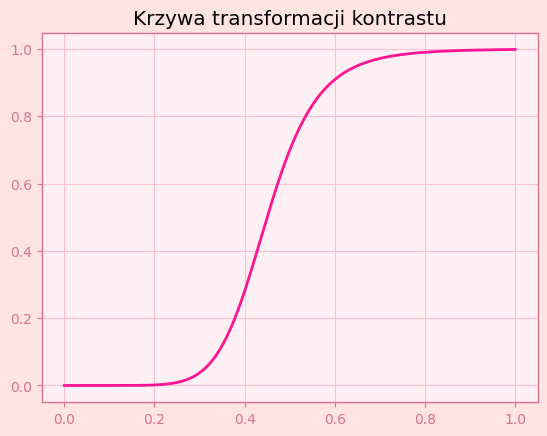

In [290]:
r = np.linspace(0, 1, 256)
m = 0.45
e = 8
s = 1 / (1 + (m / (r + 1e-6))**e)
plt.plot(r, s)
plt.title("Krzywa transformacji kontrastu")

**Obserwacje:** Wykreślenie krzywej T(r) pomaga zrozumieć działanie transformacji: niska wartość `*e*` daje płynne przejście, wysoka tworzy ostrą granicę w okolicy `*m*`. Transformacja skutecznie uwydatnia szczegóły w obrazach o małym kontraście.

Zastosowana funkcja (tzwn. *sigmoid*) pozwala na nieliniowe zwiększenie kontrastu w wybranym przedziale jasności. Parametr `*m*` (punkt przegięcia) decyduje, która wartość szarości stanie się "środkiem" nowego zakresu, a *e* definiuje "agresywność" przejścia.
- Dla obrazu `einstein-low-contrast.tif`, dobranie `*m*` w okolicy średniej jasności obrazu pozwoliło na znaczne uwypuklenie rysów twarzy, tóre wcześniej zlewały się z tłem.
- Warto zauważyć, że transformacja "wypycha" wartości w stronę ekstremów (0 i 255), co wizualnie poprawia czytelność obrazów o niskim kontraście.

### d) Korekcja gamma - s = c · r^y

In [12]:

#higher gamma values will darken the image, while lower values will brighten it. The constant c can be used to scale the output intensity range.
def gamma_correction(image: Image, gamma: float, c: float = 255) -> Image:
    img_array = np.array(image).astype(np.float64)
    normalized_array = img_array / 255.0
    modified_array = np.power(normalized_array, gamma) * c
    modified_array = np.clip(modified_array, 0, 255)
    return Image.fromarray(modified_array.astype('uint8'))

Korekcja gamma wykonywana jest w przestrzeni znormalizowanej [0, 1]:
- **y < 1** - rozjaśnienie obrazu (rozciągnięcie ciemnych tonów),
- **y > 1** - przyciemnienie obrazu (kompresja ciemnych kolorów),
- **y = 1** - brak zmiany (przekształcenie identycznościowe).

In [13]:
img = Image.open("data/aerial_view.tif")
create_image_widget(image=gamma_correction(img, 10, c=128))

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot19.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 19: Interaktywny podgląd pliku aerial_view.tiff po korekcji gamma (Wersja statyczna).</p>
</div>

Zastosowano na obrazie `aerial_view.tif` z `y = 10, c = 128` silnie przyciemnia obraz, uwydatniając strukturę jasnych obszarów.

**Obserwacja:** Korekcja gamma jest standardowym narzędziem do kompensacji nieliniowej charakterystyki monitorów i sensorów. Dobór parametru zależy od charakteru obrazu wejściowego.

Korekxja gamma jest lepszym narzędziem niż proste mnożenia, ponieważ pozwala na nieliwiowe mapowanie jasności.
- Przy `*y* > 1`, obraz staje się znacznie ciemniejszy, ponieważ funkcja potęgowa "tłumi" cienie i średnie tony, uwydatniając najjaśniejsze punkty.
- W przypadku zdjęcia lotniczego `aerial-view.tif`, pozwala to na odseparowanie jasnych struktur budynków od ciemniejszego podłoża (np. asfaltu czy roślin), co może być wstępem do automatycznej segmenatcji obiektów.

#### Wnioski

1. Dobór odpowiedniego przekształcenia punktowego zależy od charakteru informacji zawartej w obrazie: transformajca logarytmiczna jest niezastąpiona przy wizualizacji danych o szerokim zakresie (widma), podczas gdy korekcja gamma i funkcja sigmoidalna lepiej sprawdzają się w poprawie kontrastu zdjęć naturalnych i medycznych.
2. Każde z tych przekształceń zmiania kształt histogramu obrazu, co wpływa na ilość widocznych szczegółów. Należy jednak pamiętać, że nieliniowe przekształcenia (log, gamma) mogą trwale usuwać informacje w pewnych zakresach jasności (clipping).
3. Implementacja programowa z wykorzystaniem funkcji `np.clip` jest niezbędna w praktyce, aby uniknąć błędów przepełnienia typu danych (np. *wraparound* w standardzie unit8, gdzie 255 staje się 0).
4. Parametryzacja przekształceń (`*e,y,m,e*`) pozwala na elastyczne dostosowanie procesu przetwarzania do konkretnych warunków oświetleniowych, w jakich wykonywano zdjęcie.

---

## Ćwiczenie 7 - Wyrównywanie histogramu

### Cel

Zbadanie skuteczności globalnego wyrównania histogramu na obrazach o nieprawidłowej jasności (zbyt ciemnych i zbyt jasnych)


### Implementacja 

Wyrównywanie histogramu (histogram equalization) jest techniką, która mapuje poziomy szarości obrazu wejściowego tak, aby histogram obrazu wyjściowego był jak najbardziej zbliżony do rozkładu jednostajnego.
Proces ten opiera się na **dystrybuancie (CDF - Cumulative Distribution Function)** rozkładu prawdopodobieństwa wystąpienia poszczególnych poziomów jasności. Dzięki temu obszary o dużej liczebności pikseli o zbliżonej jasności zostają "rozciągnięte" na większy zakres skali szarości, co bezpośrednio przekłada się na wzrost kontrastu lokalnego.

#### Wizualizacja histogramu

In [14]:
def plot_histogram(image: Image, ignore_zeroes: bool = False, threshold: tuple = None) -> plt.Figure:
    #flatten to 1D array for histogram plotting ([[1, 2 ,3], [4,5,6],[7,8,9]] to [1, 2 ,3, 4,5,6,7,8,9])
    img_array = np.array(image).flatten()
    if ignore_zeroes:
        img_array = img_array[img_array != 0]
    if threshold is not None:
        img_array = img_array[(img_array >= threshold[0]) & (img_array <= threshold[1])]
    sns.histplot(img_array, bins=np.unique(img_array).size, kde=False) 

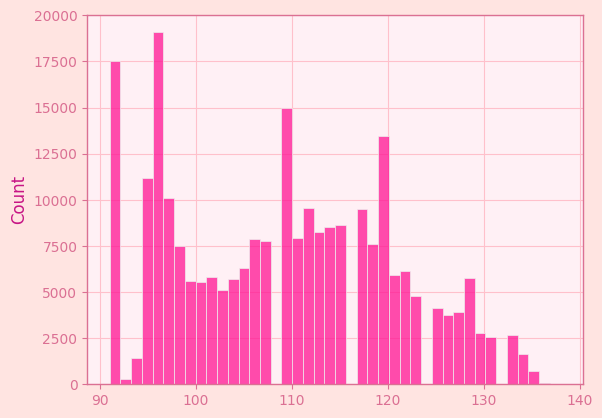

In [208]:
img = Image.open("data/pollen-lowcontrast.tif")
plot_histogram(img)

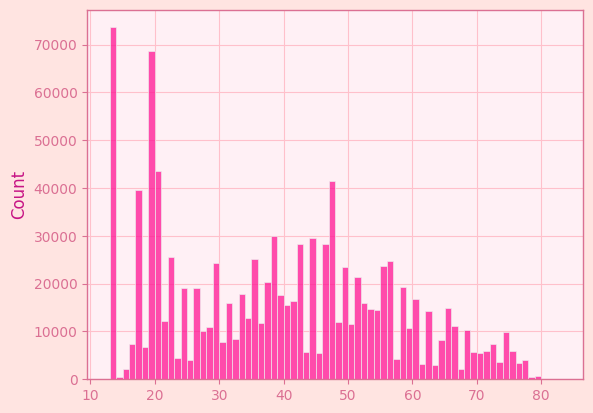

In [209]:
img = Image.open("data/pollen-dark.tif")
plot_histogram(img)

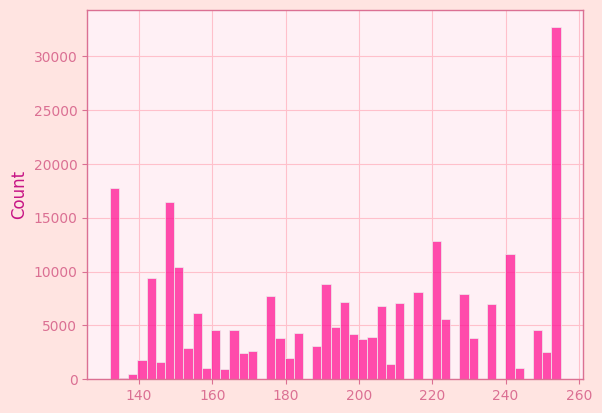

In [210]:
img = Image.open("data/pollen-ligt.tif")
plot_histogram(img)

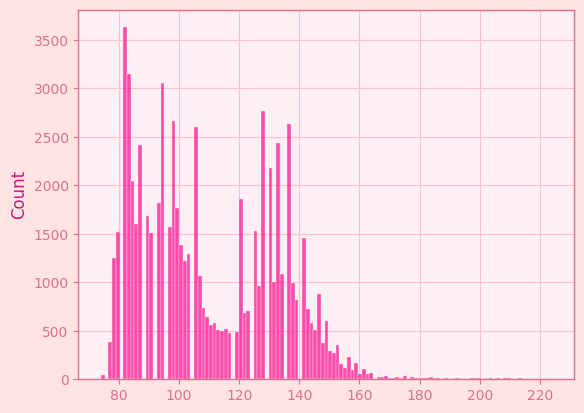

In [211]:
img = Image.open("data/pout.tif")
plot_histogram(img)

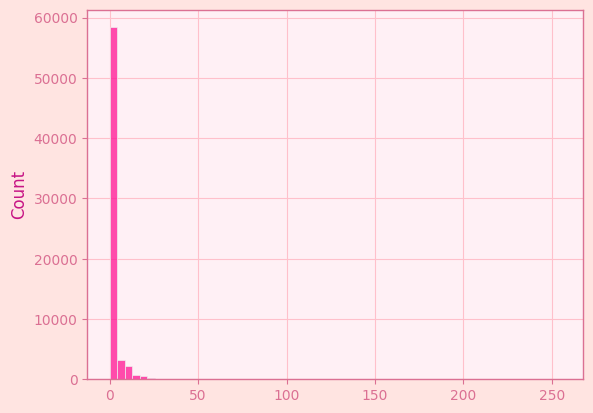

In [212]:
img = Image.open("data/spectrum.tif")
plot_histogram(img)

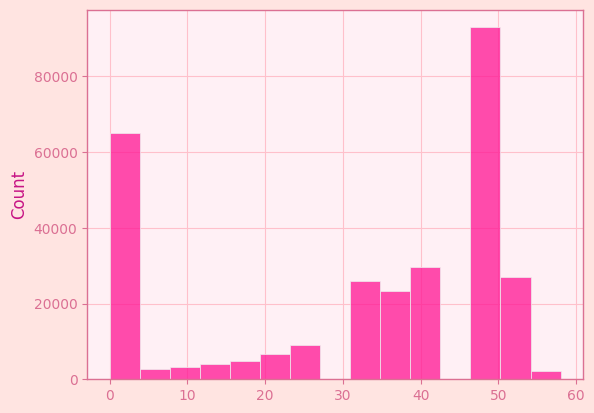

In [213]:
img = Image.open("data/chest-xray.tif")
plot_histogram(img)

Obraz spłaszczany jest do jednowymiarowej tablicy (`flatten`). Opcjonalne parametry pozwalają pominąć piksele zerowe lub ograniczyć zakres do wybranego przedziału wartości. Liczba przedziałów (binów) odpowiada liczbie unikalnych wartości szarości.

#### Globalne wyrównanie histogramu

In [16]:
def equalize_img(image: Image) -> Image:
    img_eq = cv2.equalizeHist(np.array(image, dtype=np.uint8))
    return Image.fromarray(img_eq, mode='L')

Funkcja `cv2.equalizeHist` implementuje wyrównanie histogramu przez przekształcenie oparte na dystrybuancie rozkładu wartości pikseli (CDF). W wyniku przekształcenia histogram obrazy wyjściowego jest możliwie bliski jednostajnemu. Testy przeprowadzono na: `chest_xray.tif`, `pollen-dark.tif`, `pollen-ligt.tif`, `pollen-lowcontrast.tif`, `pout.tif`, `spectrum.tif`.

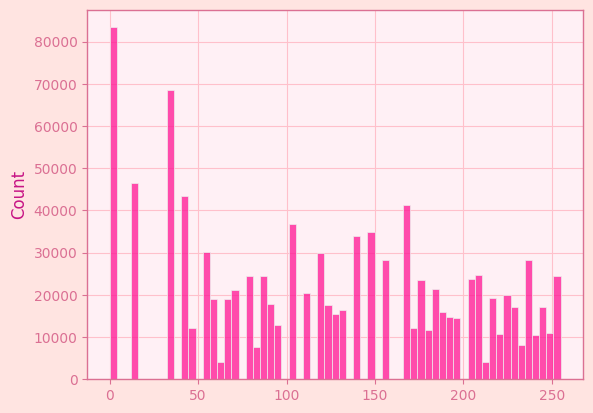

In [214]:
img = Image.open("data/pollen-dark.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)

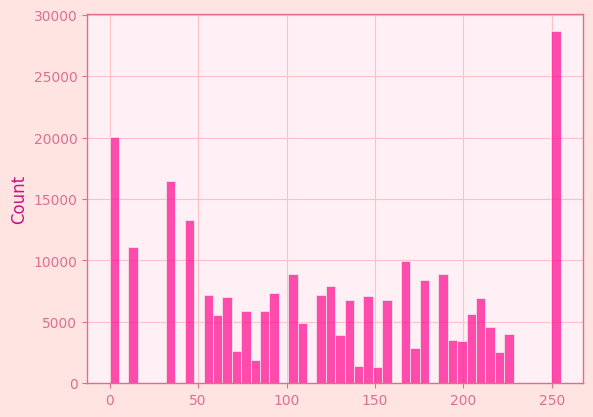

In [ ]:
img = Image.open("data/pollen-ligt.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)

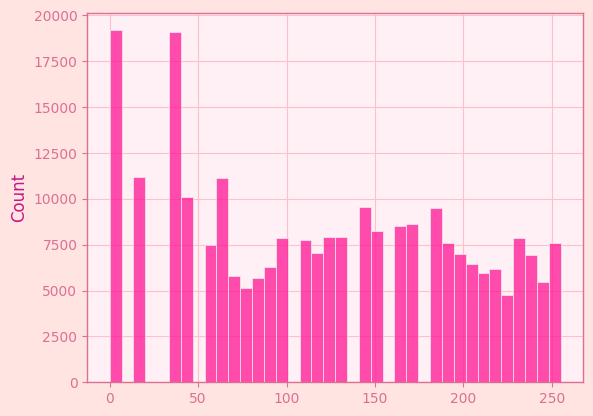

In [216]:
img = Image.open("data/pollen-lowcontrast.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)

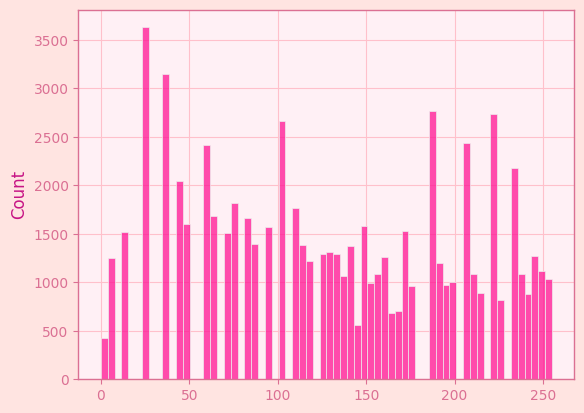

In [217]:
img = Image.open("data/pout.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)

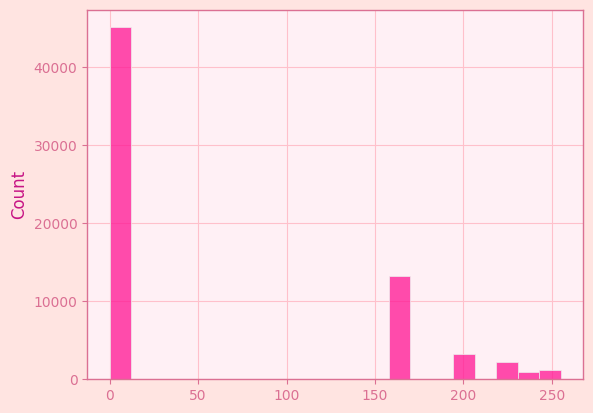

In [218]:
img = Image.open("data/spectrum.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)

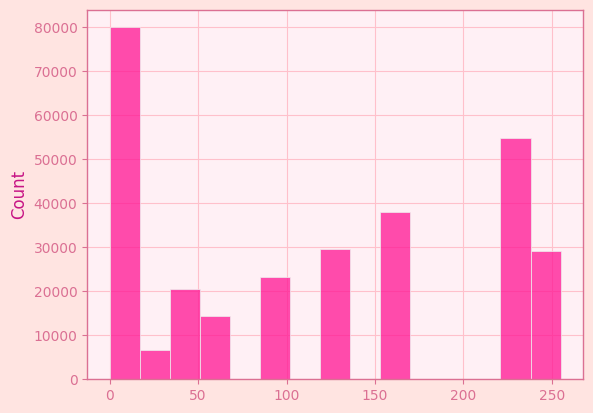

In [219]:
img = Image.open("data/chest-xray.tif")
img_eq = equalize_img(img)
plot_histogram(img_eq)


**Interpretacja histogramów obrazów:**
1. **Histogramy wejściowe**: Na wykresach dla obrazów `pollen-dark.tif` czy `pout.tif` widać wyraźne skupienie (piki) w wąskich zakresach jasności. Świadczy to o niskim kontraście - większość informacji wizualnej "sciskana" jest w małym przedziale skali szarości.
2. **Histogramy wyjściowe**: N awykresach po operacji `equalizeHist` widać, że słupki (biny) zostały rozproszone wzdłuż całej osi X (od 0 do 255). Charakterystyczne "przerwy" między słupkami wynikają z dyskretnego charakteru danych – algorytm rozciąga istniejące wartości, ale nie tworzy nowych poziomów pośrednich. Mimo tych przerw, globalny trend histogramu dąży do rozkładu płaskiego (jednostajnego).


In [18]:
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot1.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 1: Interaktywny podgląd pliku chest-xray.tiff (Wersja statyczna).</p>
</div>

In [19]:
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot20.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 20: Interaktywny podgląd pliku chest-xray.tiff po wyrównaniu histogrtamu (Wersja statyczna).</p>
</div>

W przypadku zdjęcia RTG klatki piersiowej, histogram wejściowy jest zazwyczaj silnie skoncentrowany w środkowym zakresie, co skutkuje niskim kontrastem tkanek miękkich.
- Operacja wyrównywania histogramu pozwoliła na wyraźne "wyciągnięcie" struktur anatomicznych. Żebra stały się bardziej kontrastowe względem miąższu płucnego, a naczynia krwionośne wewnątrz płuc są lepiej zdefiniowane.
- Warto zauważyć, że algorytm uwypuklił również przewody i elektrody, które przed operacją zlewały się z jaśniejszymi fragmentami kośćca. Globalne wyrównanie w tym przypadku służy jako doskonałe narzędzie do wstępnej analizy radiologicznej, ułatwiając detekcję subtelnych zmian w gęstości tkanek.

In [220]:
img = Image.open("data/pollen-dark.tif")
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot4.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 4: Interaktywny podgląd pliku pollen-dark.tiff (Wersja statyczna).</p>
</div>

In [221]:
img_eq = equalize_img(img)
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot21.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 21: Interaktywny podgląd pliku pollen-dark.tiff po wyrównaniu histogrtamu (Wersja statyczna).</p>
</div>

Obraz `pollen-dark.tif` stanowi najbardziej spektakularny przykład skuteczności wyrównywania histogramu. Histogram pierwotny był niemal całkowicie przesunięty do lewej krawędzi (wartości bliskie zeru), co sprawiało, że obraz wydawał się czarny i pozbawiony detali.
- Po wyrównaniu, "uśpiona" informacja zawarta w ciemnych pikselach została rozciągnięta na całą skalę jasności. Ujawniła się bogata, porowata tekstura ziaren pyłku oraz ich trójwymiarowy kształt.
- Jest to klasyczny przykład operacji "odzyskiwania" niedoświetlonego zdjęcia. Należy jednak odnotować wzmocnienie szumu tła – obszary, które wcześniej były idealnie czarne, teraz wykazują ziarnistość. Mimo to, z punktu widzenia analizy morfologicznej ziaren, zysk w widoczności szczegółów jest ogromny i kluczowy dla dalszych zadań (np. segmentacji czy klasyfikacji pyłków).

In [222]:
img = Image.open("data/pollen-lowcontrast.tif")
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot27.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 22: Interaktywny podgląd pliku pollen-lowcontrast.tiff (Wersja statyczna).</p>
</div>

In [223]:
img_eq = equalize_img(img)
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot22.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 23: Interaktywny podgląd pliku pollen-lowcontrast.tiff po wyrównaniu histogrtamu (Wersja statyczna).</p>
</div>

Obraz pyłku o niskim kontraście po wyrównaniu zyskał na ostrości. Szczególnie poprawiła się widoczność porowatej struktury ziaren. Warto jednak zauważyć, że w niektórych obszarach (np. w jasnych fragmentach ziaren) doszło do lekkiego "prześwietlenia", co jest typowym skutkiem ubocznym globalnego wyrównywania histogramu, który nie bierze pod uwagę lokalnych różnic oświetlenia.

In [225]:
img = Image.open("data/einstein-low-contrast.tif")
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot23.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 24: Interaktywny podgląd pliku einstein-low-contrast.tiff  (Wersja statyczna).</p>
</div>

In [226]:
img_eq = equalize_img(img)
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot24.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 25: Interaktywny podgląd pliku einstein-low-contrast.tiff po wyrównaniu histogramu (Wersja statyczna).</p>
</div>

Obraz Einsteina przed operacją jest "zamglony", co na histogramie objawia się brakiem wartości w okolicach czerni (0-50) i bieli (200-255). Po wyrównaniu, tło stało się głęboko czarne, a postać fizyka wyraźnie odcina się od otoczenia. Widoczne stały się szczegóły faktury swetra oraz detale w tle, które wcześniej były niemal niedostrzegalne. Jednak, pojawiło się sporo białego szumu, który był wcześniej niewidoczny.

In [227]:
img = Image.open("data/spectrum.tif")
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot25.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 26: Interaktywny podgląd pliku spectrum.tiff  (Wersja statyczna).</p>
</div>

In [228]:
img_eq = equalize_img(img)
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot26.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 27: Interaktywny podgląd pliku spectrum.tiff po wyrównaniu histogramu (Wersja statyczna).</p>
</div>

W przypadku widma Fouriera, wyrównywanie histogramu działa drastycznie inaczej niż transformacja logarytmiczna. Algorytm próbuje nadać taką samą wagę wizualną szumom tła i głównym składowym częstotliwościowym. Powoduje to silne uwydatnienie artefaktów i pierścieni dyfrakcyjnych w ciemnych rejonach obrazu, co jest niezwykle użyteczne przy analizie subtelnych składowych sygnału.

**Obserwacje:**
- Dla obrazów zbyt ciemnych (`pollen-dark.tif`) wyrównywanie skutecznie rozjaśnia obraz i ujawnia ukryte szczegóły.
- Dla obrazów o małym kontraście (`pollen-lowcontrast.tif`, `einstein-low-contrast.tif`) zakres dynamiczny jest wyraźnie poszerzony.
- Na obrazach `spectrum.tif` i `chest_xray.tif` efekt jest bardziej subtelny, ale histogram po wyrównaniu jest wyraźnie bardziej równomiernie rozłożony.
- Globalne wyrównanie może prowadzić do przeszacowania jasności w obszarach już dostatecznie oświetlonych.


#### Wnioski
1. Globalne wyrównywanie histogramu jest świetnym, w pełni automatycznym narzędziem do poprawy jakości zdjęć o nieprawidłowej ekspozycji lub niskim zakresie dynamicznym
2. Metoda ta najlepiej sprawdza się w obrazach, których histogram jest "ściśnięty" w jednym rejonie, ale posiada informacje w szerokim zakresie częstotliwości przestrzennych (np. zdjęcia mikrostrukturalne pyłku).
3. Głównym ograniczeniem metody globalnej (zastosowanej w ćwiczeniu) jest tendencja do nadmiernego wzmacniania szumu w obszarach o małej zmienności oraz ryzyko utraty szczegółów w bardzo jasnych lub bardzo ciemnych partiach obrazu, jeśli algorytm przesadnie rozciągnie tamtejsze poziomy szarości.
4. Porównanie histogramów "przed" i "po" pozwala na obiektywną ocenę pracy algorytmu – przejście od wąskiego piku do szerokiego rozkładu jest matematycznym potwierdzeniem wzrostu kontrastu obrazu.

---

## Ćwiczenie 8 - Lokalne metody kontekstowe 

### Cel

Sprawdzenie działania lokalnego wyrównania histogramu (CLAHE) oraz poprawy jakości opartej na lokalnych statystykach.

W przeciwieństwie do operacji punktowych, metody kontekstowe biorą pod uwagę otoczenie piksela (sąsiedztwo). Pozwala to na adaptację algorytmu do lokalnej charakterystyki obrazu.
- **CLAHE**: Rozwiązuje problem nadmiernego wzmacniania szumów w jednorodnych obszarach, który występuje w klasycznym adaptacyjnym wyrównywaniu histogramu. Dzieli obraz na kafelki (tiles), wykonuje wyrównanie, a następnie stosuje interpolację biliniową, aby wyeliminować widoczne granice między nimi.
- **Statystyki lokalne**: Metoda ta bazuje na założeniu, że interesujące nas detale (ukryte symbole) znajdują się w obszarach o niskiej jasności (mała średnia lokalna (`*ml*`) i małym kontraście (małe odchylenie standardowe `*ql*`). Poprzez selektywne wzmocnienie tylko takich obszarów, zachowujemy oryginalny wygląd reszty obrazu.

### a) Lokalne wyrównanie histogramu (CLAHE)

In [20]:
def equalize_img_locally(image: Image, clipLimit: float, tileGridSize: tuple) -> Image:
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    img_eq = clahe.apply(np.array(image, dtype=np.uint8))
    return Image.fromarray(img_eq, mode='L')

CLAHE (*Contrast Limited Adaptive Histogram Equalization*) wyrównuje histogram lokalnie w kadym kafelku o rozmiarze `tileGridSize`. Parametr `clipLimit` ogranicza maksymalną wartość histogramu w kafelku zapobiegając nadmiernemu wzmocnienu szumu. Wartośći użyte w eksperymencie: `clipLimit = 100.0`, `tileGridSize = (16, 16)`.

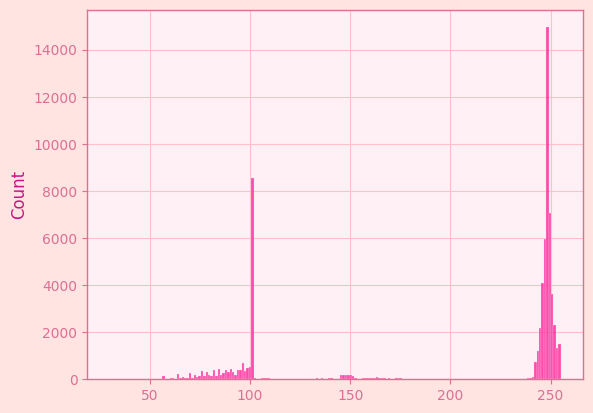

In [ ]:
img = Image.open("data/hidden-symbols.tif")
img_eq = equalize_img_locally(img, clipLimit=100.0, tileGridSize=(16,16))
plot_histogram(img_eq)

In [230]:
create_image_widget(image=img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot28.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 27: Interaktywny podgląd pliku chidden-symbols.tiff (Wersja statyczna).</p>
</div>

In [23]:
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot30.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 28: Interaktywny podgląd pliku chidden-symbols.tiff po wykonaniu operacji CLAHE (Wersja statyczna).</p>
</div>

**Obserwacja:** W porównaniu do globalnego wyrównania, CLAHE skuteczniej ujawnia szczegóły w lokalnie ciemnych lub jasnych obszarach (np. ukryte symbole na obrazie `hidden-symbols.tif`). Mniejszy kafelek oznacza bardziej lokalne działanie, ale przy zbyt małym rozmiarze może prowadzić do artefaktów.

Algorytm CLAHE wydobył wszystkie pięć symboli (kwadrat, linia skośna, litera 'a', linie poziome, koło).
- Parametr `tilwGridSize = (16,16)` zapewnia wystarczającą rozdzielczość lokalną, by "zauważyć" różnice kontrastu wewnątrz czarnych kwadratów.
- Zastosowanie `clipLimit` zapobiegło powstaniu artefaktów na dużych, jasnych połaciach tła, co jest częstym problemem przy metodach lokalnych. Histogram po operacji CLAHE jest bardziej ciągły niż w przypadku wyrównywania globalnego, co świadczy o lepszym zachowaniu tonalności obrazu.

### b) Poprawa jakości oparta na lokalnych statystykach

In [24]:
def enhance_image_locally(image: Image, c: float = 22.8 ,
                          k0: float = 0.0, 
                          k1: float = 0.1, 
                          k2: float =0.0, 
                          k3: float = 0.1,
                          size: int = 3) -> Image:
    """Enhance the image locally based on local mean and standard deviation.
       Multiplies a pixel by `c` only where the local neighborhood is both dark
       and low-contrast (i.e. its local mean and local std fall within the given
       fractions of the global statistics); all other pixels are left unchanged.

       Parameters:
       - image: Input grayscale PIL image to be enhanced.
       - c: Enhancement constant (gain) applied to qualifying pixels.
       - k0, k1: Lower/upper bounds for local mean as fractions of the global mean
              (pixel qualifies if k0*m_G <= m_L <= k1*m_G).
       - k2, k3: Lower/upper bounds for local std as fractions of the global std
              (pixel qualifies if k2*sigma_G <= sigma_L <= k3*sigma_G).
       - size: Size of the local neighborhood window (default 3 for 3x3).

    Returns:
    - Enhanced image as a PIL Image object."""
    f = np.array(image, dtype=np.float64)

    mean_local = cv2.blur(f, (size, size))
    mean_sq    = cv2.blur(f**2, (size, size))
    std_local  = np.sqrt(np.maximum(mean_sq - mean_local**2, 0))

    m_G = f.mean()
    sigma_G = f.std()

    mask = (mean_local >= k0 * m_G) & (mean_local <= k1 * m_G) & \
           (std_local  >= k2 * sigma_G) & (std_local <= k3 * sigma_G)

    enhanced = np.where(mask, c * f, f)
    enhanced = np.clip(enhanced, 0, 255)
    return Image.fromarray(enhanced.astype('uint8'))

Metoda ta wzmacnia tylko te piksele, których lokalna średnia i lokalne odchylenie standardowe mieszczą się w zadanych granicach (jako ułamki statystyk globalnych). Innymi słowy - wzmacniany jest jedynie obszar o niskim kontraście i ciemnych tonach (gdzie `k0·m_G ≤ m_L ≤ k1·m_G` oraz `k2·σ_G ≤ σ_L ≤ k3·σ_G`). Wszystkie inne piksele pozostają niezmienione.

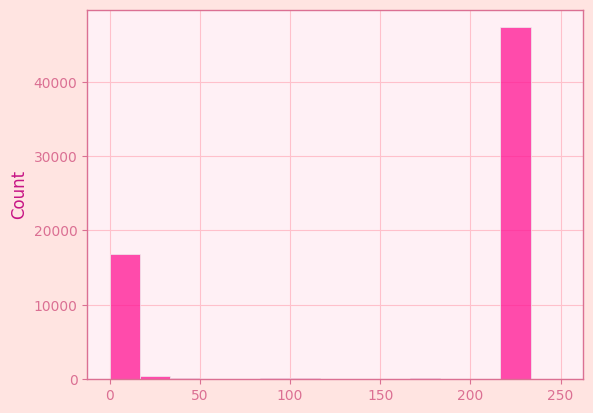

In [231]:
img_eq = enhance_image_locally(img)
plot_histogram(img_eq)

In [26]:
create_image_widget(image=img_eq)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot29.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 29: Interaktywny podgląd pliku chidden-symbols.tiff po poprawie opartej na lokalnych statystykach (Wersja statyczna).</p>
</div>

**Obserwacja:** Metoda jest precyzyjna - pozwala wydobyć słabo widoczne szczegóły bez zniekształcania pozostałych obszarów obrazu. Efektywność zależy silnie od doboru współczynników `k0` - `k3` i rozmiaru okna `size`.


Ta metoda wykazała się największą "inteligencją" w działaniu.
- Dzięki warunkom na `*ml*` oraz `*ql*`, wzmocnienie (parametr `*c*`) zostało zaaplikowane **wyłącznie** do wnętrza czarnych figur. Tło obrazu pozostało niemal nienaruszone, co widać po histogramie, który zachował swój pierwotny ształt, wzbogacając się jedynie o piki odpowiadające wzmocnionym symbolom.
- Zastosowanie okna o rozmiarze `size = 3` (3x3 piksele) pozwoliło na bardziej precyzyjne odizolowanie krawędzi symboli od ich tła. Metoda ta jest znacznie bardziej selektywna niż CLAHE i idealnie nadaje się do systemów inspekcji wizyjnej, gdzie znamy przybliżoną charakterystykę poszukiwanych defektów lub obiektów.

#### Wnioski
1. Metody lokalne (kontekstowe) są niezastąpione, gdy interesujące nas obiekty są słabo skontrastowane względem swojego bezpośredniego otoczenia, a globalne cechy obrazu (np. bardzo jasne tło) dominują nad jego lokalną strukturą.
2. **CLAHE** jest metodą bardziej uniwersalną - nie wymaga precyzyjnej wiedzy o parametrach obiektu, a jedynie dobrania rozmiaru kafelka i limitu wzmocnienia. Jest to standard w poprawie jakości zdjęć medycznych i satelitarnych.
3. **Poprawa oparta na statystykach lokalnych** daje bajbardziej estetyczne i precyzyjne wyniki (nie zmienia tła), ale wymaga żmudnego dostrajania parametrów `*ko, k1, k2, k3*`. Jest to technika typu "chirurgicznego" w przetwarzaniu obrazów.
4. Rozmiar okna kontekstowego (maski) ma kluczowe znacznie: zbyt małe okno może wzmacniać pojedyńcze piksele szumu, natomiast zbyt duże okno powoduje, że algorytm "traci z oczu" małe detale, uśredniając je z otoczeniem. 
5. Obraz `hidden-symbols.tif` udowodnił, że ludzkie oko może nie dostrzegać informacji, która jest matematycznie obecna w pliku cyfrowym - odpowiednie algorytmy kontekstowe pozwalają na pełne wydobycie tej ukrytej treści.
---

## Ćwiczenie 9 - Filtracja dolnoprzepustowa: redukcja szumu "sól i pieprz" 

### Cel 

Ocena skutecznośći filtrów liniowych i nieliniowych w redukcji szumu impulsowego na obrazach: `cboard_pepper_only.tif`, `cboard_salt_only.tif`,`cboard_salt_pepper.tif`.

Szum typu "sól i pieprz" (impulsowy) charakteryzuje się występowaniem pikseli o ekstremalnych wartościach jasności (0 lub 255), które są całkowicie niezależne od treści obrazu.
- **Filtr uśredniający (liniowy)**: Działa jak operator splotu. Próbuje ""rozmyć" energię impulsu na sąsiednie piksele. Matematycznie jest to mało efektywne, ponieważ jedna wartość 255 w oknie 3x3 znacząco podnosi średnią całego bloku.
- **Filtr medianowy (nieliniowy)**: Jest filtrem rangowym. Wybiera wartość środkową z posortowanego zbioru pikseli w oknie. Ponieważ impulsy szumu są wartościami ekstremalnymi (autlierami), lądują na końcach posortowanej listy i niemal nigdy nie są wybierane jako mediana.
- **Filtry min/max**: To operacje morfologiczne (erozja i dylatacja). Wykorzystują statystyki ekstremalne do selektywnej eliminacji lub ciemnych artefaktów.

### a) Liniowy filtr uśredniający

In [27]:
def linear_avg_filter(image: Image, kernel_size: int) -> Image:
    avraged = cv2.blur(np.array(image), (kernel_size, kernel_size))
    return Image.fromarray(avraged.astype('uint8'))

Każdy piksel zastępowany jest średnią arytmetyczną pikseli w kwadratowym sąsiedztwie o rozmiarze `kernel_size x kernel_size`. Implementacja opiera się na `cv2.blur`

In [235]:
img = Image.open("data/cboard_salt_pepper.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot31.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 30: Interaktywny podgląd pliku cboard_salt_pepper.tiff (Wersja statyczna).</p>
</div>

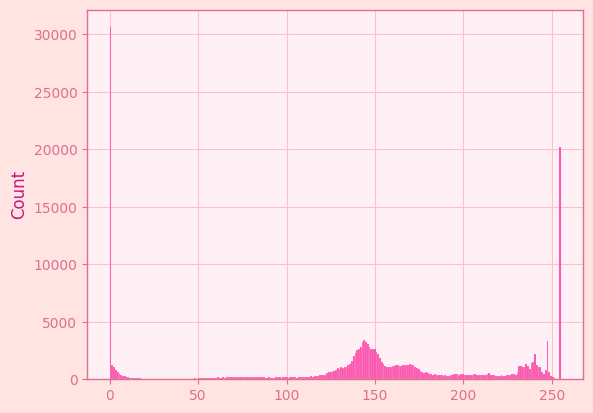

In [236]:
plot_histogram(img)

In [237]:
img_filtered = linear_avg_filter(img, kernel_size=5)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot32.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 31: Interaktywny podgląd pliku cboard_salt_pepper.tiff po zastosowaniu liniowego filtra uśredniającego (Wersja statyczna).</p>
</div>

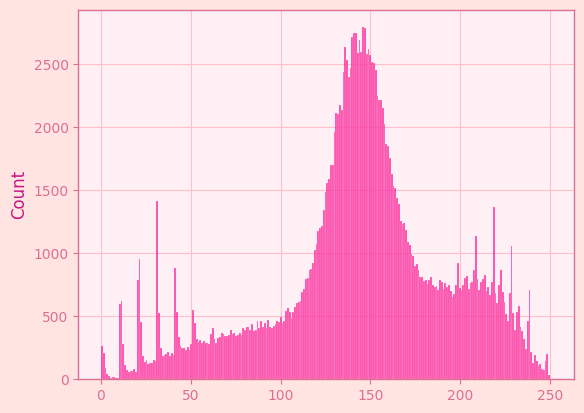

In [238]:
plot_histogram(img_filtered)

In [239]:
img = Image.open("data/cboard_pepper_only.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot33.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 32: Interaktywny podgląd pliku cboard_pepper_only.tiff (Wersja statyczna).</p>
</div>

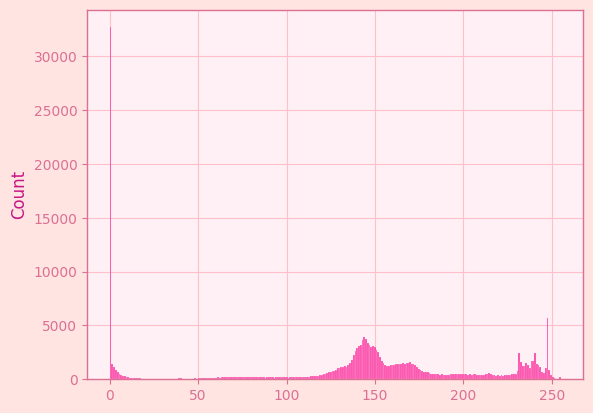

In [240]:
plot_histogram(img)

In [241]:
img_filtered = linear_avg_filter(img, kernel_size=5)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot34.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 33: Interaktywny podgląd pliku cboard_pepper_only.tiff po zastosowaniu liniowego filtra uśredniającego (Wersja statyczna).</p>
</div>

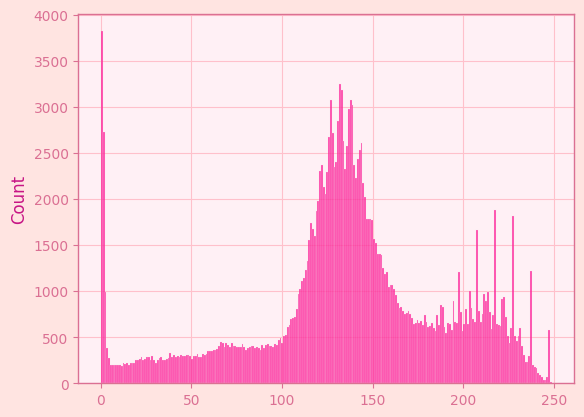

In [242]:
plot_histogram(img_filtered)

In [243]:
img = Image.open("data/cboard_salt_only.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot35.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 34: Interaktywny podgląd pliku cboard_salt_only.tiff (Wersja statyczna).</p>
</div>

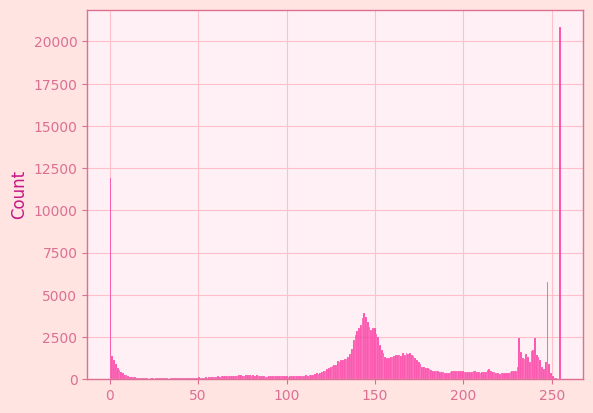

In [244]:
plot_histogram(img)

In [245]:
img_filtered = linear_avg_filter(img, kernel_size=5)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot36.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 35: Interaktywny podgląd pliku cboard_salt_only.tiff po zastosowaniu liniowego filtra uśredniającego (Wersja statyczna).</p>
</div>

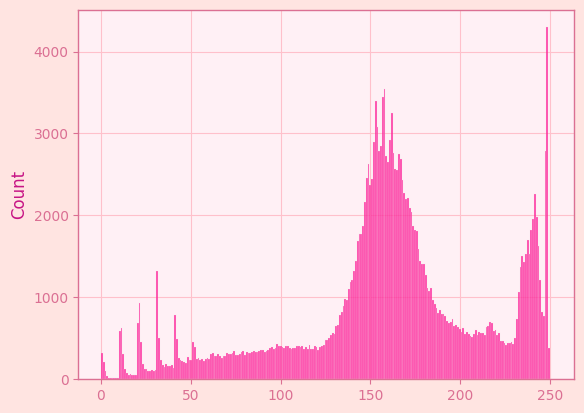

In [246]:
plot_histogram(img_filtered)

**Obserwacja:** Filtr uśredniający skutecznie redukuje szum, ale jednocześnie rozmywa krawędzie. Im większa maska, tym silniejsze rozmycie i lepsza redukcja szumu,a le kosztem utraty ostrości. Dla szumu "sól i pieprz" jest mniej skuteczny niż filtr medianowy - jasne/ciemne punkty są jedynie "rozmywane", a nie eliminowane.

Na hostogramach po filtracji uśredniającej widać, że piki odpowiadające za szum (wartości 0 i 255) zniknęły, ale w zamian histogram stał się szerszy i bardziej rozmyty.
- Wizualnie przekąłda sie to na powstanie "szarych plam" w miejscach, gdzie wcześniej był szum.
- Krawędzie płytki straciły na swoją ostrość - filtr liniowy nie potrafi odróżnić szumu od istotnej krawędzi obrazu, traktując oba zjawiska jako wysokie częstotliwości do wytłumienia.

### b) Filtr medianowy

In [32]:
def median_filter(image: Image, kernel_size: int) -> Image:
    medianed = cv2.medianBlur(np.array(image), kernel_size)
    return Image.fromarray(medianed.astype('uint8'))

Każdy piksel zastępowany jest medianą wartości w sąsiedztwie. Filtr medianowy jest **nieliniowy** i wyjątkowo skuteczny dla szumu "sól i pieprz", ponieważ wartości ekstremalne (0 lub 255)nie wpływają na medianę, tak jak wpływają na średnią.

In [247]:
img = Image.open("data/cboard_salt_pepper.tif")
img_filtered = median_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot37.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 36: Interaktywny podgląd pliku cboard_salt_pepper.tiff po zastosowaniu filtra medianowego (Wersja statyczna).</p>
</div>

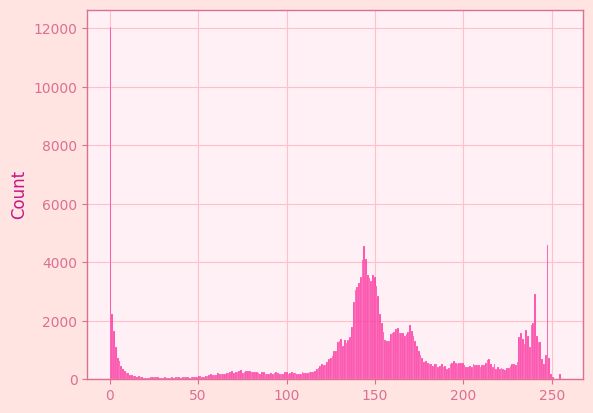

In [248]:
plot_histogram(img_filtered)

In [249]:
img = Image.open("data/cboard_pepper_only.tif")
img_filtered = median_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot38.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 37: Interaktywny podgląd pliku cboard_pepper_only.tiff po zastosowaniu filtra medianowego (Wersja statyczna).</p>
</div>

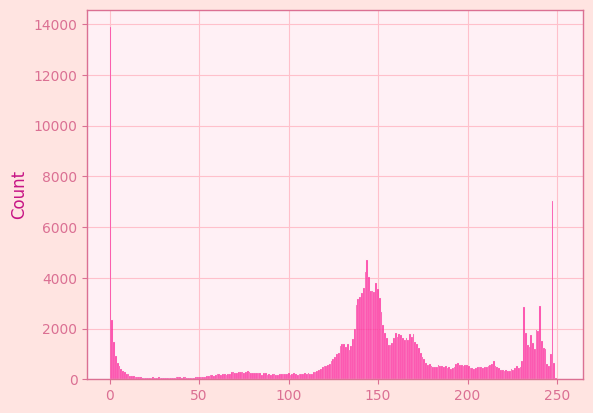

In [250]:
plot_histogram(img_filtered)

In [252]:
img = Image.open("data/cboard_salt_only.tif")
img_filtered = median_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot39.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 38: Interaktywny podgląd pliku cboard_salt_only.tiff po zastosowaniu filtra medianowego (Wersja statyczna).</p>
</div>

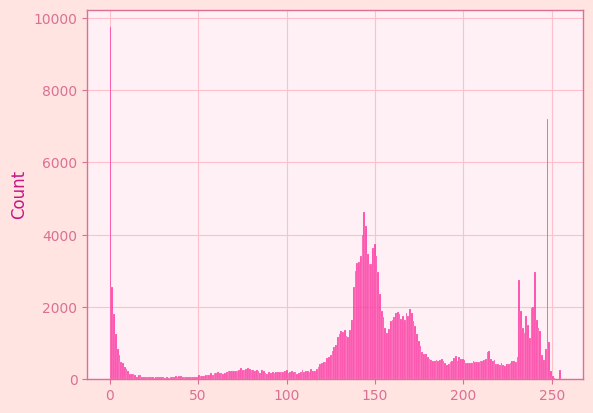

In [253]:
plot_histogram(img_filtered)

**Obserwacja:** Już maska 3x3 eliminuje szum impulsowy przy minimalnym rozmyciu krawędzi. Medianowy jest wyraźnie lepszy ni uśredniający dla tego rodzaju szumu.

To najbardziej efektywna metoda dla tego zestawu danych.
- Histogram po filtracji medianowej jest niemal identyczny z histogramem idelanego, czystego obrazu. Algorytm całkowicie usunął impulsy, nie wprowadzając wartości pośrednich (szarości) tam, gdzie cih nie było.
- Krawędzie obiektów pozostały idealnie ostre. Jest to unikalna cecha filtrów medianowych - potrafią one redukować szum o dużej amplitudzie, zachowując jednocześnie skokowe zmiany jasności (krawędzie).

### c) Filtr minimum i maksimum

Filtr minimum zastępuje każdy piksel **najmniejszą** wartością w oknie - skutecznie eliminuje szum typu "sól" (białe punkty), ale przyciemnia obraz.

In [35]:
def min_filter(image: Image, kernel_size: int) -> Image:
    min_filtered = ndimage.minimum_filter(np.array(image), size=kernel_size)
    return Image.fromarray(min_filtered.astype('uint8'))

In [261]:
img = Image.open("data/cboard_salt_pepper.tif")
img_filtered = min_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot40.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 39: Interaktywny podgląd pliku cboard_salt_pepper.tiff po zastosowaniu filtru minimum (Wersja statyczna).</p>
</div>

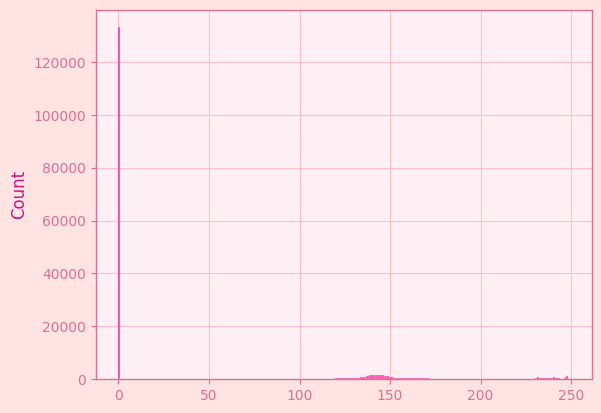

In [262]:
plot_histogram(img_filtered)

In [263]:
img = Image.open("data/cboard_pepper_only.tif")
img_filtered = min_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot41.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 40: Interaktywny podgląd pliku cboard_pepper_only.tiff po zastosowania filtra minimum (Wersja statyczna).</p>
</div>

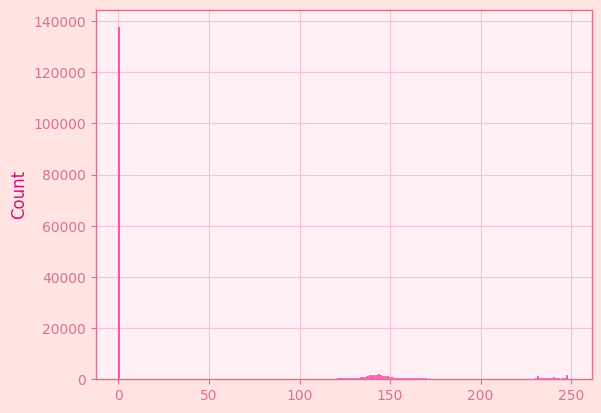

In [264]:
plot_histogram(img_filtered)

In [265]:
img = Image.open("data/cboard_salt_only.tif")
img_filtered = min_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot42.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 41: Interaktywny podgląd pliku cboard_salt_only.tiff po zastosowaniu filtru minimum (Wersja statyczna).</p>
</div>

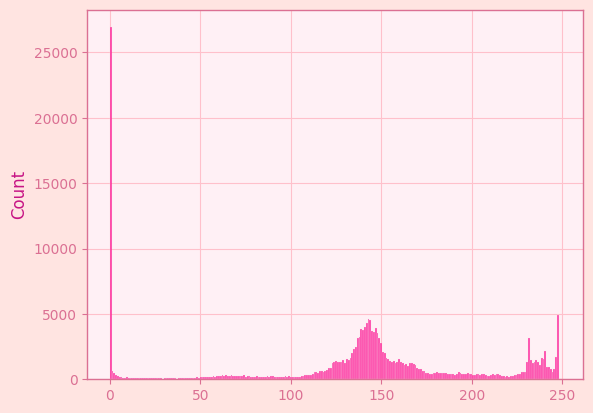

In [266]:
plot_histogram(img_filtered)

Filtr maksimum stosuje analogiczną operację (do filtru minimum) z **największą** wartością - eliminuje szu "pieprz" (czarne punkty), ale rozjaśnia obraz.

In [38]:
def max_filter(image: Image, kernel_size: int) -> Image:
    max_filtered = ndimage.maximum_filter(np.array(image), size=kernel_size)
    return Image.fromarray(max_filtered.astype('uint8'))

In [267]:
img = Image.open("data/cboard_salt_pepper.tif")
img_filtered = max_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot43.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 42: Interaktywny podgląd pliku cboard_salt_pepper.tiff po zastosowaniu filtru maksimum (Wersja statyczna).</p>
</div>

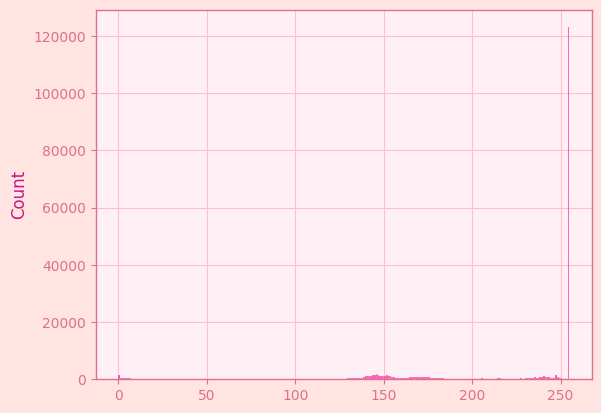

In [268]:
plot_histogram(img_filtered)

In [270]:
img = Image.open("data/cboard_pepper_only.tif")
img_filtered = max_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot44.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 43: Interaktywny podgląd pliku cboard_pepper_only.tiff po zastosowaniu filtra maksimum (Wersja statyczna).</p>
</div>

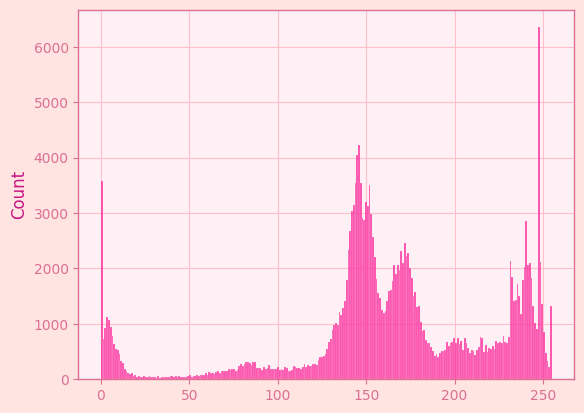

In [271]:
plot_histogram(img_filtered)

In [272]:
img = Image.open("data/cboard_salt_only.tif")
img_filtered = max_filter(img, kernel_size=3)
create_image_widget(img_filtered)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot45.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 44: Interaktywny podgląd pliku cboard_salt_only.tiff po zastosowaniu filtra maksimum (Wersja statyczna).</p>
</div>

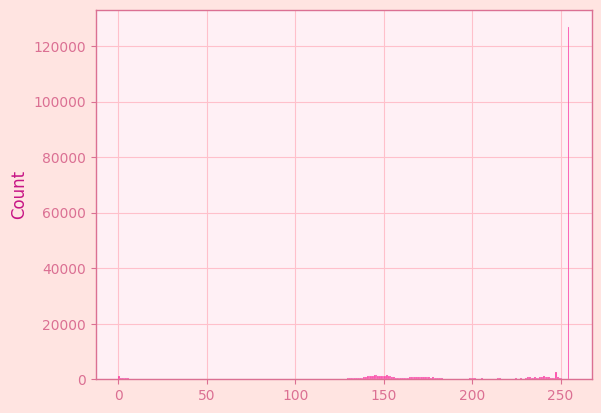

In [273]:
plot_histogram(img_filtered)

- **Filtr minimum** doskonale poradził sobie z obrazem `cboard_salt_only`, ponieważ "białe ziarna soli" (255) zawsze przegrywały z ciemniejszym tłrm podczas wyboru wartości minimalnej. Jednakże, na obrazie z "pieprzem", filtr ten powiększył czarne kropki, co jest efektem dylatacji ciemnych obszarów.
- **Filtr maksimum** zadziałał odwrotnie - idealnie wyczyścił "pieprz",a le na obrazie z "solą" spowodował rozlanie się białych plam.
- Zastosowanie filtra minimum na obrazie mieszanym usuwa sól, alw uwypukla pieprz, co potwierdza asymetryczny charakter tych operatorów.

#### Wnioski
1. Do redukcji szumu impulsowego ("sól i pieprz") filtry nieliwowe są bezkonkurencyjne. Filtr medianowy pozwala na całkowite usunięcie zakłóceń przy zerowej lub minimalnej degradacji ostrości obrazu.
2. Filtry liniowe (uśredniające) są niewłaściwym wyborem dla szumu S&P. Zamiast usuwać szum, przekształcają go w rozmyte plamy, które są równie uciążliwe w dalszej analizie (np. utrudniają segmentację).
3. Filtry min/max mogą być stosowane jako szybkie detektory typu szumu - jeśli filtr Max czyści obraz idealnie, wiemy, że dominującym zakłóceniem był szum typu "pieprz".
4. Zwiększanie rozmiaru maski (np. z 3x3 na 5x5 lub 7x7) w filtrze medianowym pozwala na usunięcie gęstszego szumu, ale przy bardzo dużych maskach zaczynają zniakć małe detale obrazu (np. rogi kwadratów na szachownicy ulegają zaokrągleniu).
5. Analiza histogramu "po" filtracji jest najlepszym sposobem na sprawdzenie, czy algorytm rzeczywiście usunął wartości ekstremalne (0 i 255), czy jedynie przesunął je w stronę średniej.

---

## Ćwiczenie 10 - Filtreacja dolnoprzepustowa: filtr uśredniający i gaussowki

### Cel

Zbadanie wpływu rozmiaru maski na wynik filtracji dolnoprzepustowej na obrazach `characters_test_pattern.tif` i `zoneplate.tif`.
Zbadaj działanie dolnoprzepustowych filtrów uśredniającego i gaussowskiego dla danych obrazów.


Filtracja dolnoprzepustowa ma na celu wygładzenie obrazu poprzez tłumienie wysokich częstotliwości przestrzennych (odpowiadających za krawędzie i drobne detale).
- **Filtr uśredniający (Box Filter)**: Najprostsza forma wygłaszania. Każdy piksel w masce ma taką samą wagę (`*1/N*`). W dziedzinie częstotliwości jego charakterystka to funkcja *sinc*, co powoduje powstanie nieopożądanych artefaktów (tzw. dzwonienia) na ostrych krawędziach.
- **Filtr Gaussa**: Jest filtrem optymalnym, ponieważ jego funkcja wagowa jest gładka i maleje wraz z odległością od centrum. Matematycznie, splot obrazu z funkcją Gaussa w dziedzinie przestrzennej jest równoważny filtracji dolnoprzepustowej w dziedzinie częstotliwości bez wprowadzania gwałtownych zniekształceń fazowych. Parametr `*q*` (odchylenie standardowe) definuje "szerokość" dzwonu Gaussa i tym samym siłę rozmycia.

In [292]:
img = Image.open("data/characters_test_pattern.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot46.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 45: Interaktywny podgląd pliku characters_test_pattern.tiff (Wersja statyczna).</p>
</div>

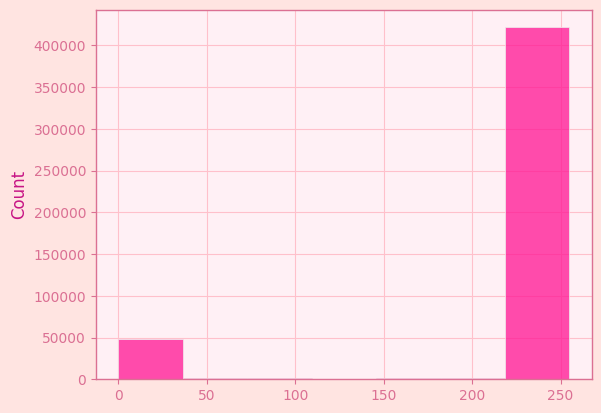

In [293]:
plot_histogram(img)

In [276]:
img = Image.open("data/zoneplate.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot47.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 46: Interaktywny podgląd pliku zoneplate.tiff (Wersja statyczna).</p>
</div>

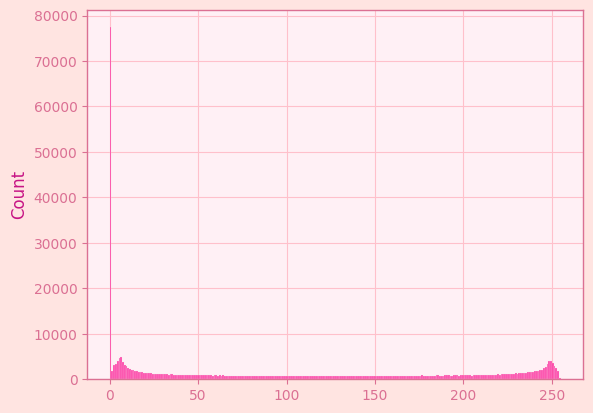

In [277]:
plot_histogram(img)

### Implementacja

Filtr uśredniający - ponowne użycie `linear_avg_filter` z ćw. 9

In [ ]:
img = Image.open("data/characters_test_pattern.tif")
filtered_avg = linear_avg_filter(img, kernel_size=5)
create_image_widget(filtered_avg)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot48.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 47: Interaktywny podgląd pliku characters_test_pattern.tiff po zastosowaniu filtra uśredniającego (Wersja statyczna).</p>
</div>

In [279]:
img = Image.open("data/zoneplate.tif")
filtered_avg = linear_avg_filter(img, kernel_size=5)
create_image_widget(filtered_avg)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot49.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 48: Interaktywny podgląd pliku zoneplate.tiff po zastosowaniu filtra uśredniającego (Wersja statyczna).</p>
</div>

**Obserwacja:** Filtr uśredniający skutecznie redukuje szum, ale jednocześnie rozmywa krawędzie. Im większa maska, tym silniejsze rozmycie i lepsza redukcja szumu, ale kosztem utraty ostrości. Dla szumu „sól i pieprz" jest mniej skuteczny niż filtr medianowy – jasne/ciemne punkty są jedynie „rozmywane", a nie eliminowane.


Na obrazie z literami wyraźnie widać degradację czytelności tekstu wraz ze wzrostem maski.
**Filtr uśredniający** powoduje, że krawędzie liter stają się "rozmyte", a mniejsze znaki zlewają sie w nieczytelne plamy. Przy większych maskach pojawiają się artefakty w postaci "cieni" wokół czarnych obiektów. 

In [44]:
def gaussian_filter(image: Image, kernel_size: int) -> Image:
    gaussian_filtered = cv2.GaussianBlur(np.array(image), (kernel_size, kernel_size), sigmaX=0) # sigmaX=0 means that the function will calculate the sigma based on the kernel size.
    return Image.fromarray(gaussian_filtered.astype('uint8'))

Filtr gaussowski waży piksele zgodnie z rozkładem Gaussa - piksele bliżej centum okna mają większy wpływ na wyniki niż te na jego obrzeżach. `sigmaX=0` oznacza automatyczne wyznaczanie parametru σ na podstawie rozmiaru maski.

In [281]:
img = Image.open("data/characters_test_pattern.tif")
filtered_gaussian = gaussian_filter(img, kernel_size=5)
create_image_widget(filtered_gaussian)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot50.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 49: Interaktywny podgląd pliku characters_test_pattern.tiff po zastosowaniu filtra gaussowskiego (Wersja statyczna).</p>
</div>

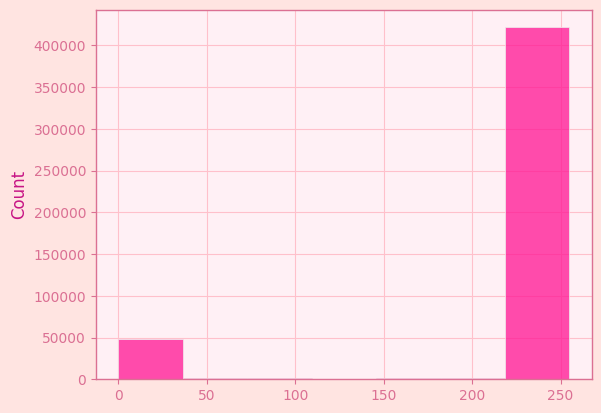

In [282]:
plot_histogram(img)

In [283]:
img = Image.open("data/zoneplate.tif")
filtered_gaussian = gaussian_filter(img, kernel_size=9)
create_image_widget(filtered_gaussian)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot51.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 50: Interaktywny podgląd pliku zoneplate.tiff po zastosowaniu filtra gaussowskiego (Wersja statyczna).</p>
</div>

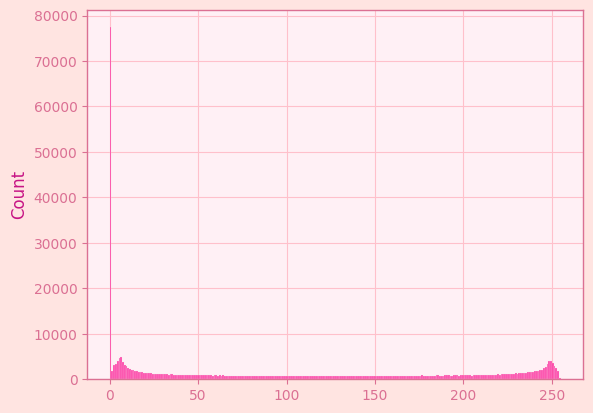

In [284]:
plot_histogram(img)

**Filtr Gaussa** przy tej samej wielkości maski zachowują lepszą czytelność krawędzi. Rozmycia jest bardziej estetyczne i płynne, co sprawia, że litery, choć mniej ostre, są łatwiejsze do rozpoznania przez ludzkie oko niż w przypadku filtra uśredniającego.

**Analiza w dziedzinie częstotliwości:** Obraz `zoneplate` jest generowany tak, że częstotliwość wzrasta wraz z odległością od centrum.
- **Efekt dolnoprzepustowy:** W obu przypadkach centrum obrazu (niskie częstotliwości) pozostaje wyraźne, podczas gdy zewnętrzne pierścienie (wysokie częstotliwości) ulegają wytłumieniu i szarzeją.
- **Różnica:** Filtr uśredniający wykazuje charakterystyczne "listki boczne" - niektóre wysokie częstotliwości są przepuszczane bardziej niż inne, co widać jako nierównomierne szare pasy na obrzeżach. Filtr Gaussa działa bardziej selektywnie i monotonicznie - płynnie wycina wysokie częstotliwości, pozostawiając czyte, rozmyte przejście od centrum ku krawędziom.

**Wpływ na histogram:** Filtracja dolnoprzepustowa powoduje "zwężenie" histogramu. Skrajne wartości (czysta czerń i biel) są zastępowane wartościami uśrednionymi (odcieniami szarości). Na wykresach histogramu po filtracji widać, że biny przesuwają się w stronę wartości średniej, a wysokie piki przy 0 i 255 maleją. Im większa maska, tym bardziej histogram koncentruje się wokół jedenej, średniej wartości jasności obrazu.

**Obserwacje:**
- Oba filtry rozmywają obraz; filtr gaussoowski daje bardziej naturalne, łagodniejsze rozmycie.
- Filtr uśredniający może powodować charakterystyczne artefakty (dzwonienie) widoczne zwłaszcza na wzorcach `characters_test_pattern.tif`.
- Zwiększanie rozmiaru maski proporcjonalnie zwiększa stopień rozmycia i niszczy drobne szczegóły (małe znaki tekstowe, wysokie częstotliwości przestrzenne na obrazie `zoneplate.tif`).
- Filtr gaussowski ogólnie jest preferowany nad uśredniającym ze względu na lepsze własciwości w dziedzinie częstotliwości.

#### Wnioski
1. Wybór rozmiaru maski (`*3x3, 5x5 i 7x7*` itd.) jest kompromisem między stopniem redukcji zakłóceń a zachowaniem ostrości detali. Przy maskach powyżej `*7x7*`informacja o małych obiektach (tekście) jest niemal całkowicie tracona.
2. Filtr Gaussa jest znaczie lepszym narzędziem do ogólnego wygłoadzania obrazów niż prosty filtr uśredniający, ponieważ nie wprowadza artefaktór "dzwonienia" i lepiej zachowuje strukturę totalną obrazu.
3. Autoamtyczny dobór parametru `*q*` w OpenCV (`sigmaX=0`) na podstawie rozmiaru maski zapewnia optymalny profil dzownu Gaussa, co minimalizuje ryzyko zniekształcenia obrazu przy danej rozdzielczości filtracji.
4. Test na obrazie `zoneplate` udowodnił, że filtry dolnoprzepustopowe działają jako idealne tłumiki wysokich częstotliwości przestrzennych, co jest kluczowe w procesach takich jak usuwanie ziarnistości czy przygotowanie obrazu do operacji segmentacji.

---

## Ćwiczenie 11 - Filtracja górnoprzepustowa: krawędzie i wyostrzanie

### Cel

a) Detekcja krawędzi filtrem Sobela (poziomych, pionowych, ukośnych),
b) Wyostrzanie laplasjanem,
c) Unsharp marking i high boost


Celem filtracji górnoprzepustowej jest uwydatnienie nagłych zmian jasności (krawędzi i detali) poprzez tłumienie składowych o niskich częstotliwościach przestrzennych.
- **Operator Sobela:** Wykorzystuje pochodne cząstkowe pierwszego rzędu. Dzięki zastosowaniu uśredniania w kierunku prostopadłym do różniczkowania, jest on relatywnie odporny na szum, dając stabilne wyniki detekcji krawędzi kierunkowych.
- **Laplasjan:** Wykorzystuje drugą pochodną. Jest operatorem izotropowym (niezależnym od kierunku), co czyni go idealnym do detekcji punktów i cienkich linii, ale również czyni go bardzo wrażliwym na szum.
- **Unsharp Masking / High Boost:** Techniki te nie są filtrami w ścisłym tego słowa znaczeniu, lecz procedurami, które wykorzystują maskę (różnicę między oryginałem a obrazem rozmytym) do selektywnego wzmocnienia wysokich częstotliwości.

In [285]:
img = Image.open("data/circuitmask.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot52.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 51: Interaktywny podgląd pliku circuitmask.tiff (Wersja statyczna).</p>
</div>

In [286]:
img = Image.open("data/testpat1.png")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot53.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 52: Interaktywny podgląd pliku testpat1.png (Wersja statyczna).</p>
</div>

### a) Filtry Sobela

#### Krawędzie pionowe (gradient poziomy)

In [48]:
def sobel_column_filter(image: Image.Image) -> Image.Image:
    arr = np.array(image.convert('L')) 
    sobel_x = cv2.Sobel(arr, cv2.CV_64F, 1, 0, ksize=3) # use built in sobel kernel for column detection
    sobel_x = np.abs(sobel_x)
    sobel_x = (sobel_x / sobel_x.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_x.astype('uint8'))

Parametry `dx = 1, dy = 0` oznaczają różniczkowanie w kierunku X (wykrywanie pionowych krawędzi). Wyknik normalizowany jest do zakresu [0, 255].

In [192]:
img = Image.open("data/circuitmask.tif")
filtered_img = sobel_column_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot54.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 53: Interaktywny podgląd pliku circuitmask.tiff po zastosowaniu filtru Sobela pionowego (Wersja statyczna).</p>
</div>

In [196]:
img = Image.open("data/testpat1.png")
filtered_img = sobel_column_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot55.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 54: Interaktywny podgląd pliku testpat1.png po zastosowaniu filtru Sobela pionowego (Wersja statyczna).</p>
</div>

#### Krawędzie poziome (gradient pionowy)

In [50]:
def sobel_row_filter(image: Image) -> Image:
    arr = np.array(image.convert('L')) 
    sobel_y = cv2.Sobel(arr, cv2.CV_64F, 0, 1, ksize=3) # use built in sobel kernel for row detection
    sobel_y = np.abs(sobel_y)
    sobel_y = (sobel_y / sobel_y.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_y.astype('uint8'))

Parametry `dx = 0, dy = 1` - różniczowkanie w kierunku Y (wykrywanie poziomych krawędzi)

In [ ]:
img = Image.open("data/circuitmask.tif")
filtered_img = sobel_row_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot56.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 55: Interaktywny podgląd pliku circuitmask.tif po zastosowaniu filtru Sobela poziomego (Wersja statyczna).</p>
</div>

In [197]:
img = Image.open("data/testpat1.png")
filtered_img = sobel_row_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot57.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 56: Interaktywny podgląd pliku testpat1.png po zastosowaniu filtru Sobela poziomego (Wersja statyczna).</p>
</div>

#### Gradient sumaryczny (krawędzie ukośne)

In [52]:
def sobel_magnitude_filter(image: Image) -> Image: # can dtect diagonal edges
    arr = np.array(image.convert('L'))
    sobel_x = cv2.Sobel(arr, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(arr, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(sobel_x, sobel_y)
    magnitude = np.abs(magnitude)
    magnitude = (magnitude / magnitude.max() * 255).astype(np.uint8)
    return Image.fromarray(magnitude.astype('uint8'))

Magnituda grafdientu `sqrt(Gx² + Gy²)` wykrywa krawędzie we wszystkich kierunkach jednocześnie, w tym ukośne.

In [194]:
img = Image.open("data/circuitmask.tif")
filtered_img = sobel_magnitude_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot58.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 57: Interaktywny podgląd pliku circuitmask.tiff po zastosowaniu sumarycznego filtru Sobela (Wersja statyczna).</p>
</div>

In [198]:
img = Image.open("data/testpat1.png")
filtered_img = sobel_magnitude_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot59.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 58: Interaktywny podgląd pliku testpat1.png po pzastosowaniu sumarycznego filtru Sobela (Wersja statyczna).</p>
</div>

#### Krawędzie ukośne (własne maski)

Zaimplementowano dwie dodatkowe maski Sobela dla krawędzi skośnych:

Ukos lewo-prawo
`k_diag1 = np.array([[  0,  1,  2],
                     [ -1,  0,  1],
                     [ -2, -1,  0]], dtype = np.float64)`

Ukos prawo-lewo
`k_diag2 = np.array([[ -2, -1,  0],
                     [ -1,  0,  1],
                     [  0,  1,  2]], dtype = np.float64)`     

Maski stosowane przy pomocy `cv2.filter2D`.      

In [54]:
def sobel_diagonal_left_right_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    k_diag1 = np.array([[ 0,  1,  2],
                        [-1,  0,  1],
                        [-2, -1,  0]], dtype=np.float64)
    sobel_diag_lr = cv2.filter2D(arr, cv2.CV_64F, k_diag1)
    sobel_diag_lr = np.abs(sobel_diag_lr)
    sobel_diag_lr = (sobel_diag_lr / sobel_diag_lr.max() * 255).astype(np.uint8)
    return Image.fromarray(sobel_diag_lr.astype('uint8'))

In [ ]:
img = Image.open("data/circuitmask.tif")
filtered_img = sobel_diagonal_left_right_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot60.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 59: Interaktywny podgląd pliku circuitmask.tiff po zastosowaniu filtru Sobela z własnymi maskami (lewo-prawo) (Wersja statyczna).</p>
</div>

In [199]:
img = Image.open("data/testpat1.png")
filtered_img = sobel_diagonal_left_right_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot61.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 60: Interaktywny podgląd pliku testpat1.png po zastosowaniu filtru Sobela z własnymi maskami (lewo-prawo)(Wersja statyczna).</p>
</div>

In [56]:
def sobel_diagonal_right_left_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    k_diag2 = np.array([[-2, -1,  0],
                    [-1,  0,  1],
                    [ 0,  1,  2]], dtype=np.float64)
    sobel_diag_rl = cv2.filter2D(arr, cv2.CV_64F, k_diag2)
    sobel_diag_rl = np.abs(sobel_diag_rl)
    sobel_diag_rl = (sobel_diag_rl / sobel_diag_rl.max() * 255).astype(np.uint8) 
    return Image.fromarray(sobel_diag_rl.astype('uint8'))

In [ ]:
img = Image.open("data/circuitmask.tif")
filtered_img = sobel_diagonal_right_left_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot62.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 61: Interaktywny podgląd pliku circuitmask.tiff po zastosowaniu filtru Sobela z własnymi maskami (prawo-lewo)(Wersja statyczna).</p>
</div>

In [200]:
img = Image.open("data/testpat1.png")
filtered_img = sobel_diagonal_right_left_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot63.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 62: Interaktywny podgląd pliku testpat1.png po zastosowaniu filtru Sobela z własnymi maskami (prawo-lewo) (Wersja statyczna).</p>
</div>

Porównanie wyników dla maski `circuitmask.tif` pokazuje, że filtry kierunkowe Sobela precyzyjnie wyodrębniają ścieżki o konkretnej orientacji.
- **Sobel X** uwidocznił krawędzie pionowe, całkowicie pomijając poziome linie ścieżek.
- **Magnituda gradientu** łączy informacje z obu kierunków, dając pełny obrys obiektów. Jest to kluczowy krok w systemach wizyjnych służących do pomiarów geometrycznych elementów na płytkach PCB.
- Zastosowanie **masek ukośnych** pozwoliło na detekcję struktur pod kątem 45° i 135°, co jest szczególnie widoczne na wzorcu testowym `testpat1.png`

### b) Laplasjan - wyostrzanie szczegółów

In [58]:
img = Image.open("data/blurry-moon.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot64.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 63: Interaktywny podgląd pliku blurry-moon.tiff (Wersja statyczna).</p>
</div>

Laplasjan jest operatorem różniczkowania drugiego rzędu - wykrywa obszary szybkich zmian intęsywności (krawędzie i narożniki) we wszystkich kierunkach jednocześnie.

In [59]:
def laplacian_filter(image: Image) -> Image:
    arr = np.array(image.convert('L'))
    laplacian = cv2.Laplacian(arr, cv2.CV_64F)
    laplacian = np.abs(laplacian)
    laplacian = (laplacian / laplacian.max() * 255).astype(np.uint8)
    return Image.fromarray(laplacian.astype('uint8'))

In [60]:
filtered_img = laplacian_filter(img)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot65.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 64: Interaktywny podgląd pliku blurry-moon.tiff po zastosowaniu filtru Laplasjana (Wersja statyczna).</p>
</div>

Wyostrzanie przez odjęcie laplasjanu od obrazu oryginalnego (`s = f - ∇²f`) wzmacnia krawędzie o dorbne szczegóły. Zastosowanie na obrazie `blurry-moon.tif`.

In [61]:
def laplacian_sharpen(image: Image.Image) -> Image.Image:
    arr = np.array(image.convert('L'), dtype=np.float64)
    laplacian = cv2.Laplacian(arr, cv2.CV_64F)
    sharpened = arr - laplacian               
    sharpened = np.clip(sharpened, 0, 255)
    return Image.fromarray(sharpened.astype('uint8'))

In [62]:
filtered_img = laplacian_sharpen(img)
create_image_widget(filtered_img)
 

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot66.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 65: Interaktywny podgląd pliku blurry-moon.tiff po zastosowaniu filtru Laplasjana i wyostrzeniu (Wersja statyczna).</p>
</div>

**Obserwacja:** Po wyostrzaniu laplasjanem wyraźnie widoczne stają się kratery i szczegóły powierzchni Księżyca, niewidoczne na rozmytym oryginale.

Zastosowanie Laplasjanu jako narzędzia do wyostrzania (`f - ∇²f`) pozwoliło na odzyskanie detali, które zostały utracone w procesie akwizycji lub przez dyfrakcję w optyce (obraz `blurry-moon.tif`). Na Rysunku 65 widać, że granice kraterów stały się twardsze, a mikrotekstura powierzchni Księżyca zyskała na wyrazistości. Należy jednak zauważyć, że w obszarach tła (czarnych) wzrosła widoczność szumu kwantyzacji.

### c) Unsharp masking i high boost

In [63]:
img = Image.open("data/text-dipxe-blurred.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot67.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 66: Interaktywny podgląd pliku blurry-moon.tiff (Wersja statyczna).</p>
</div>

In [64]:
def unsharp_masking(image: Image, amount: float) -> Image:
    arr = np.array(image, dtype=np.float64)
    blurred = cv2.GaussianBlur(arr, (3, 3), sigmaX=0)
    unsharp_mask = arr - blurred                    
    sharpened = arr + amount * unsharp_mask
    sharpened = np.clip(sharpened, 0, 255)
    return Image.fromarray(sharpened.astype('uint8'))

Algorytm działa w trzech krokach:
1. Rozmycie obrazu filtrem gaussowskim -> `blurred`,
2. Obliczanie maski wyostrzającej: `unsharp_mask = oryginalny - rozmyty` (wyodrębnianie wysokich częstotliwości),
3. Dodanie maski do oryginalnego z wagą `amunt` : `s = f + amount · (f - blurred)`.

Dla `amount = 1` to klasyczny *unsharp masking*. Dla `amount > 1` (np. 30) jest to *high boost filtering* - znacznie silniejsze wyostrzenie, kosztem wzmocnienia szumu.

Stosowane na `text-dipxe-blurred.tif`.

In [65]:
filtered_img = unsharp_masking(img, amount=1.0) # amount = 1 : normal nsharp masking
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot68.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 67: Interaktywny podgląd pliku blurry-moon.tiff po zastosowaniu normal unsharp masking (Wersja statyczna).</p>
</div>

In [66]:
filtered_img = unsharp_masking(img, amount=30) # amount > 1 : normal high boost
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot69.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 68: Interaktywny podgląd pliku blurry-moon.tiff po zastosowaniu high boost (Wersja statyczna).</p>
</div>

**Obserwacja:** Unsharp masking przywraca czytelność rozmytego tekstu. High boost (duże `amount`) wyostrza jeszcze silniej, ale jednocześnie amplifikuje ewentualny szum.

Obraz `text-dipxe-blurred.tif` jest typowym przykładem tekstu o niskiej czytelności z powodu rozmycia.
- **Unsharp Masking** amount=1.0) przywrócił ostrość krawędzi liter, czyniąc tekst znacznie bardziej czytelnym dla systemów OCR (Optical Character Recognition).
- **High Boost** (amount=30.0) ekstremalnie wzmocnił kontrast krawędziowy. Choć tekst wydaje się bardzo wyraźny, wewnątrz liter pojawiają się artefakty (ziarnistość), co jest efektem nadmiernego wzmocnienia składowych o najwyższych częstotliwościach. Metoda ta jest niezwykle użyteczna przy obrazach o bardzo niskim kontraście wyjściowym.


#### Wnioski
1. Detekcja krawędzi filtrem Sobela pozwala na skuteczną analizę strukturalną obrazu, umożliwiając selektywne badanie obiektów o określonej orientacji.
2. Wyostrzanie Laplasjanem jest metodą szybką i skuteczną dla obrazów o wysokim stosunku sygnału do szumu (SNR), jednak przy obrazach zaszumionych może prowadzić do niepożądanej amplifikacji zakłóceń.
3. Procedura Unsharp Masking oferuje lepszą kontrolę nad procesem wyostrzania niż czysty Laplasjan, ponieważ pozwala na regulację siły efektu (parametr `amount`) oraz stopnia wygładzenia maski (poprzez `sigma` filtru Gaussa).
4. High Boost Filtering jest potężnym rozszerzeniem metody unsharp masking, pozwalającym na wydobycie szczegółów z obrazów silnie zdegradowanych, gdzie standardowe metody wyostrzania okazują się niewystarczające.
5. Wszystkie techniki filtracji górnoprzepustowej wymagają ostrożności w implementacji (stosowanie typu `float64` i funkcji `clip`), aby uniknąć błędów wynikających z ujemnych wartości pochodnych i przepełnienia zakresu jasności.


---

## Ćwiczenie 12 - Poprawa jakości przez wieloetapowe przetwarzanie

### Cel

Kompleksowa poprawa jakości obrazu `bonescan.tif` przez kolejne stosowanie różnych przekształceń.


### Pipeline przetwarzania

In [151]:
img = Image.open("data/bonescan.tif")
create_image_widget(img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot70.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 69: Interaktywny podgląd pliku bonescan.tiff (Wersja statyczna).</p>
</div>

#### Krok 1 - Korekcja gamma

In [152]:
img_transformed = gamma_correction(img, 0.5, c=200)
create_image_widget(img_transformed)
# img_transformed = contrast_transformation(img, 40, 3)
# create_image_widget(img_transformed)


Output()

<div style="text-align: center;">
    <img src="plot_stills/plot71.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 70: Interaktywny podgląd pliku bonescan.tiff po zastosowaniu korekcji gamma (Wersja statyczna).</p>
</div>

Korekcja gamma z `y = 0.5` (rozjaśnienie) uwydatnia szczegóły w ciemnych obszarach scyntygrafii kości. Wartość `c = 200` ogranicza maksymalną jasność wyjścia.
Wyjściowy obraz scyntygraficzny posiada większość informacji skumulowanej w niskich rejestrach jasności. Zastosowanie korekcji gamma pozwoliło na nieliniowe rozciągnięcie ciemnych tonów. Dzięki temu zarys sylwetki oraz struktura kręgosłupa stały się widoczne, co stanowi fundament dla dalszych operacji wyostrzania.

#### Krok 2 - Lokalne wyrównywanie histogramu (CLAHE)

In [153]:
img_equalised = equalize_img_locally(img_transformed, clipLimit=5.0, tileGridSize=(3,3))
create_image_widget(img_equalised)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot72.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 71: Interaktywny podgląd pliku bonescan.tiff po lokalnym wyrównaniu histogramu (CLAHE) (Wersja statyczna).</p>
</div>

CLAHE z małym kafelkiem `(3, 3)` i umiarkowanym `clipLimit = 5.0` poprawia lokalny kontrast, ujawniając zróżnicowanie intęsywności w poszczególnych obszarach kości. Mały kafelek zapewnia precyzyjne działanie lokalne.
Globalne rozjaśnienie (Krok 1) nie wystarczyło, by ukazać różnice w gęstości kośćca. Zastosowanie CLAHE z bardzo małym kafelkiem `(3, 3)` pozwoliło na ekstremalne uwydatnienie lokalnych różnic jasności. Na tym etapie obraz staje się "czytelny", ale jednocześnie pojawia się silny szum cyfrowy, wynikający z natury samej metody adaptacyjnej.


#### Krok 3 - Wyostrzanie laplasjanem

In [289]:
sharpened_img = laplacian_sharpen(img_equalised)
create_image_widget(sharpened_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot73.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 72: Interaktywny podgląd pliku bonescan.tiff po wyostrzeniu Laplasjanem (Wersja statyczna).</p>
</div>

Wyostrzanie laplacjanem wzmacnia krawędzie i kontury anatomiczne, poprawiając czytelność diagnostyczną obrazu.
Celem tego kroku było wzmocnienie wysokich częstotliwości (krawędzi kości). Odjęcie Laplasjanu od obrazu z poprzedniego kroku spowodowało, że kontury żeber i miednicy stały się "twardsze" i wyraźniej odcięte od tkanek miękkich. Jest to kluczowy etap z punktu widzenia diagnostyki obrazowej.

#### Krok 4 - Filtr medianowy

In [155]:
filtered_img = median_filter(sharpened_img, kernel_size=9)
create_image_widget(filtered_img)

Output()

<div style="text-align: center;">
    <img src="plot_stills/plot74.png" width="90%" style="border: 2px solid #FFB6C1; border-radius: 10px;">
    <p style="color: #DB7093; font-style: italic;">Rysunek 73: Interaktywny podgląd pliku bonescan.tiff po zastosowaniu filtru medianowego (Wersja statyczna).</p>
</div>

Duży filtr medianowy (`9x9`) na końcu pipeline usuwa artefakty i szum wprowadzony przez poprzednie operacje, wygładzając obraz przy zachowaniu krawędzi.
Poprzednie kroki (szczególnie CLAHE i Laplasjan) drastycznie zwiększyły poziom szumu w obrazie. Zastosowanie filtra medianowego o masce `9x9` było niezbędne do wygładzenia finalnego wyniku. Dzięki nieliniowej naturze filtra, szum został usunięty, a wypracowane wcześniej ostre krawędzie struktur kostnych zostały w dużej mierze zachowane, co daje estetyczny i użyteczny medycznie obraz końcowy.

### Wnioski z ćwiczenia 12

Wieloetapowe podejście pozwala uzyskać znacznie lepszy rezultat niż pojedyńcze przekształcenie:
- Korekcja gamma i CLAHE - odpowiadają za globalną i lokalną poprawę jasności/kontrastu,
- Laplasjan - wydobywa szcegóły strukturalne,
- Filtr medianowy - redukuje szumy końcowe bez rozmycia krawędzi.

Kolejnośc operacji ma kluczowe znaczenie: wyostrzanie powinno odbywać poprzedzać wygładzanie, a korekcja tonalna powinna być pierwszym krokiem. Eksperyment z alternatywnym podejściem (`contrast_transformation` zamiast korekcji gamma) zostały oznaczone w kodzie jako zakomentowane, co świadczy o przeprowadzeniu porównania obu wariantów.

Dodatkowo:
1. Żadne z pojedynczych przekształceń nie dałoby tak dobrego rezultatu jak ich sekwencyjne złożenie. Każdy etap przygotowywał dane pod kolejny algorytm (tzw. preprocessing).
2. Kluczowym aspektem była kontrola szumu – wzmacnianie kontrastu i ostrości zawsze wiąże się z degradacją stosunku sygnału do szumu (SNR), dlatego pipeline musiał zostać domknięty filtrem odszumiającym (mediana).
3. Scyntygrafia kości po przejściu przez ten proces stała się znacznie bardziej informatywna – struktury, które na oryginale były jedynie szarymi plamami, teraz posiadają wyraźne granice i widoczną teksturę.

---


## Podsumowanie

W trakcie laboratorium zaimplementowano i przetestowano szeroki zestaw metod przetwarzania obrazów cyfrowych:
- **Przekształcenia punktowe** (mnożenie, logarytm, kontrast, gamma) – kształtowanie tonalności i kontrastu obrazu,
- **Wyrównywanie histogramu** (globalne i lokalne CLAHE) – automatyczna poprawa kontrastu,
- **Lokalne statystyki** – selektywne wzmacnianie wybranych obszarów,
- **Filtry dolnoprzepustowe** (uśredniający, gaussowski, medianowy, min, max) – redukcja szumów,
- **Filtry górnoprzepustowe** (Sobel, Laplasjan, unsharp masking) – detekcja krawędzi i wyostrzanie,
- **Wieloetapowe przetwarzanie** – kompozycja przekształceń dla złożonej poprawy jakości.
Wszystkie funkcje zostały zaimplementowane w sposób modularny i zintegrowane z interaktywnym widgetem w środowisku Jupyter Notebook. Takie podejście pozwoliło na błyskawiczną obserwację wpływu parametrów (np. rozmiaru maski czy stałej gamma) na wynik, co jest niezbędne w procesie projektowania systemów wizyjnych i diagnostycznych. Doświadczenia te udowodniły, że dobór odpowiedniej metody zależy ściśle od specyfiki danych wejściowych i celu, jaki chcemy osiągnąć.

In [207]:
#uniform notebook design
pink_theme = """
<style>
    #notebook-container {
        background-color: #FFF0F5 !important;
        box-shadow: 0px 0px 15px rgba(255, 105, 180, 0.3) !important;
        border-radius: 15px;
    }
    div.cell.code_cell {
        background-color: #FFF5EE !important;
        border-left: 5px solid #FF1493 !important;
    }
    div.text_cell_render {
        font-family: 'Georgia', serif;
        color: #000000 !important;
    }
    .widget-label { 
        color: #C71585 !important;
        font-weight: bold;
    }
    .jupyter-button {
        background-color: #FFB6C1 !important;
        color: white !important;
        font-weight: bold;
        border-radius: 10px;
    }
    .jupiter-button:hover {
        background-color: #FF69B4 !important;
    }
</style>
"""
display(HTML(pink_theme))